# AirFly Insights - Airlines Flight Data Analysis

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# Settings for better display
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## MILESTONE 1 - WEEK 1: Project Setup

## Step 2: Load All 3 Datasets

Loading airlines, airports, and flights data

In [3]:
# Load airlines dataset
airlines = pd.read_csv(r"data/airlines.csv")
print(f"✓ Airlines loaded: {len(airlines)} airlines")

✓ Airlines loaded: 14 airlines


In [4]:
# Load airports dataset
airports = pd.read_csv(r"data/airports.csv")
print(f"✓ Airports loaded: {len(airports)} airports")

✓ Airports loaded: 322 airports


In [5]:
# Load flights dataset (main data - 5.8 million records)
flights = pd.read_csv(r"data/flights.csv", low_memory=False)
print(f"✓ Flights loaded: {len(flights):,} records with {len(flights.columns)} columns")

✓ Flights loaded: 5,819,079 records with 31 columns


## Step 3: Merge Datasets

Combining flights with airline names and airport information

In [6]:
# Merge flights with airline names (rename to avoid column conflicts)
df = flights.merge(
    airlines.rename(columns={'AIRLINE': 'AIRLINE_NAME'}),
    left_on='AIRLINE',
    right_on='IATA_CODE',
    how='left'
)

# Drop the redundant IATA_CODE column
df.drop(columns=['IATA_CODE'], inplace=True, errors='ignore')

# Merge with origin airport info
df = df.merge(
    airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']],
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE',
    how='left',
    suffixes=('', '_ORIGIN')
)
df.rename(columns={'AIRPORT': 'ORIGIN_AIRPORT_NAME', 'CITY': 'ORIGIN_CITY', 'STATE': 'ORIGIN_STATE'}, inplace=True)

# Merge with destination airport info
df = df.merge(
    airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']],
    left_on='DESTINATION_AIRPORT',
    right_on='IATA_CODE',
    how='left',
    suffixes=('', '_DEST')
)
df.rename(columns={'AIRPORT': 'DEST_AIRPORT_NAME', 'CITY': 'DEST_CITY', 'STATE': 'DEST_STATE'}, inplace=True)

# Drop redundant IATA_CODE columns
df.drop(columns=['IATA_CODE', 'IATA_CODE_ORIGIN'], inplace=True, errors='ignore')

print(f"✓ Datasets merged successfully!")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✓ Datasets merged successfully!
Final shape: 5,819,079 rows × 39 columns


## Step 4: Initial Data Exploration

Let's examine our merged dataset

In [7]:
# Dataset overview
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.columns

Dataset: 5,819,079 rows × 39 columns


Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'AIRLINE_NAME',
       'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'IATA_CODE_DEST',
       'DEST_AIRPORT_NAME', 'DEST_CITY', 'DEST_STATE'],
      dtype='object')

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,5819079.0,NaN,NaN,NaN,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,628,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,629,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0


## MILESTONE 1 - WEEK 2: Data Cleaning & Feature Engineering

## Step 5: Data Cleaning

Cleaning the data by handling missing values and fixing data types

In [9]:
# Create working copy for cleaning
df_clean = df.copy()
print(f"✓ Starting data cleaning on {len(df_clean):,} rows")

✓ Starting data cleaning on 5,819,079 rows


In [10]:
# Check for duplicate rows (memory-efficient approach)
sample_size = 100000
if len(df_clean) > sample_size:
    sample_dup_rate = df_clean.head(sample_size).duplicated().sum() / sample_size
    if sample_dup_rate < 0.01:
        print(f"✓ Duplicate check: <1% duplicates detected (skipped for memory efficiency)")
    else:
        before = len(df_clean)
        df_clean = df_clean.drop_duplicates()
        print(f"✓ Removed {before - len(df_clean):,} duplicate rows")
else:
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    print(f"✓ Removed {before - len(df_clean):,} duplicate rows")

✓ Duplicate check: <1% duplicates detected (skipped for memory efficiency)


In [11]:
# Handle missing values in delay columns (missing = 0 delay)
delay_columns = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 
                 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

for col in delay_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
print(f"✓ Filled missing delay values with 0 for {len(delay_columns)} columns")

✓ Filled missing delay values with 0 for 7 columns


In [12]:
# Handle cancellation data
if 'CANCELLATION_REASON' in df_clean.columns:
    df_clean['CANCELLATION_REASON'] = df_clean['CANCELLATION_REASON'].fillna('None')
if 'CANCELLED' in df_clean.columns:
    df_clean['CANCELLED'] = df_clean['CANCELLED'].fillna(0).astype(int)
print("✓ Cleaned cancellation data (1=cancelled, 0=not cancelled)")

✓ Cleaned cancellation data (1=cancelled, 0=not cancelled)


## Step 5.1: Outlier Detection using IQR Method

Identifying outliers in numerical columns using the Interquartile Range (IQR) method

**Insights:**
- The four box plots summarize the distributions of DEPARTURE_DELAY, ARRIVAL_DELAY, DISTANCE, and AIR_TIME.
- Delays are right-skewed: the median is below the upper quartile and many outliers appear on the high side, indicating a small fraction of severe delays.
- DISTANCE and AIR_TIME show broader spread with fewer extreme outliers relative to delays, consistent with operational routing.
- The whisker lengths and outlier density highlight which metrics have the largest variability; ARRIVAL_DELAY typically mirrors DEPARTURE_DELAY but with added spread from in-flight factors.

In [13]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    """
    Detect outliers in a column using the IQR method
    Returns: lower_bound, upper_bound, outlier_count, outlier_percentage
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(data)) * 100
    
    return lower_bound, upper_bound, outlier_count, outlier_percentage

# Select numerical columns for outlier detection
numerical_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_TIME', 'DISTANCE', 
                  'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                  'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

# Check which columns exist in the dataset
available_cols = [col for col in numerical_cols if col in df_clean.columns]

print("Outlier Detection Summary (IQR Method)")
print("=" * 80)

outlier_summary = []
for col in available_cols:
    lower, upper, count, percentage = detect_outliers_iqr(df_clean, col)
    outlier_summary.append({
        'Column': col,
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}",
        'Outlier Count': f"{count:,}",
        'Outlier %': f"{percentage:.2f}%"
    })
    print(f"\n{col}:")
    print(f"  Lower Bound: {lower:.2f} | Upper Bound: {upper:.2f}")
    print(f"  Outliers: {count:,} ({percentage:.2f}%)")

print("\n" + "=" * 80)
print("Outlier detection completed!")


Outlier Detection Summary (IQR Method)

DEPARTURE_DELAY:
  Lower Bound: -23.00 | Upper Bound: 25.00
  Outliers: 736,242 (12.65%)

DEPARTURE_DELAY:
  Lower Bound: -23.00 | Upper Bound: 25.00
  Outliers: 736,242 (12.65%)

ARRIVAL_DELAY:
  Lower Bound: -43.00 | Upper Bound: 37.00
  Outliers: 539,002 (9.26%)

ARRIVAL_DELAY:
  Lower Bound: -43.00 | Upper Bound: 37.00
  Outliers: 539,002 (9.26%)

AIR_TIME:
  Lower Bound: -66.00 | Upper Bound: 270.00
  Outliers: 296,342 (5.09%)

AIR_TIME:
  Lower Bound: -66.00 | Upper Bound: 270.00
  Outliers: 296,342 (5.09%)

DISTANCE:
  Lower Bound: -660.50 | Upper Bound: 2095.50
  Outliers: 349,511 (6.01%)

DISTANCE:
  Lower Bound: -660.50 | Upper Bound: 2095.50
  Outliers: 349,511 (6.01%)

AIR_SYSTEM_DELAY:
  Lower Bound: 0.00 | Upper Bound: 0.00
  Outliers: 564,826 (9.71%)

SECURITY_DELAY:
  Lower Bound: 0.00 | Upper Bound: 0.00
  Outliers: 3,484 (0.06%)

AIR_SYSTEM_DELAY:
  Lower Bound: 0.00 | Upper Bound: 0.00
  Outliers: 564,826 (9.71%)

SECURITY_DELA

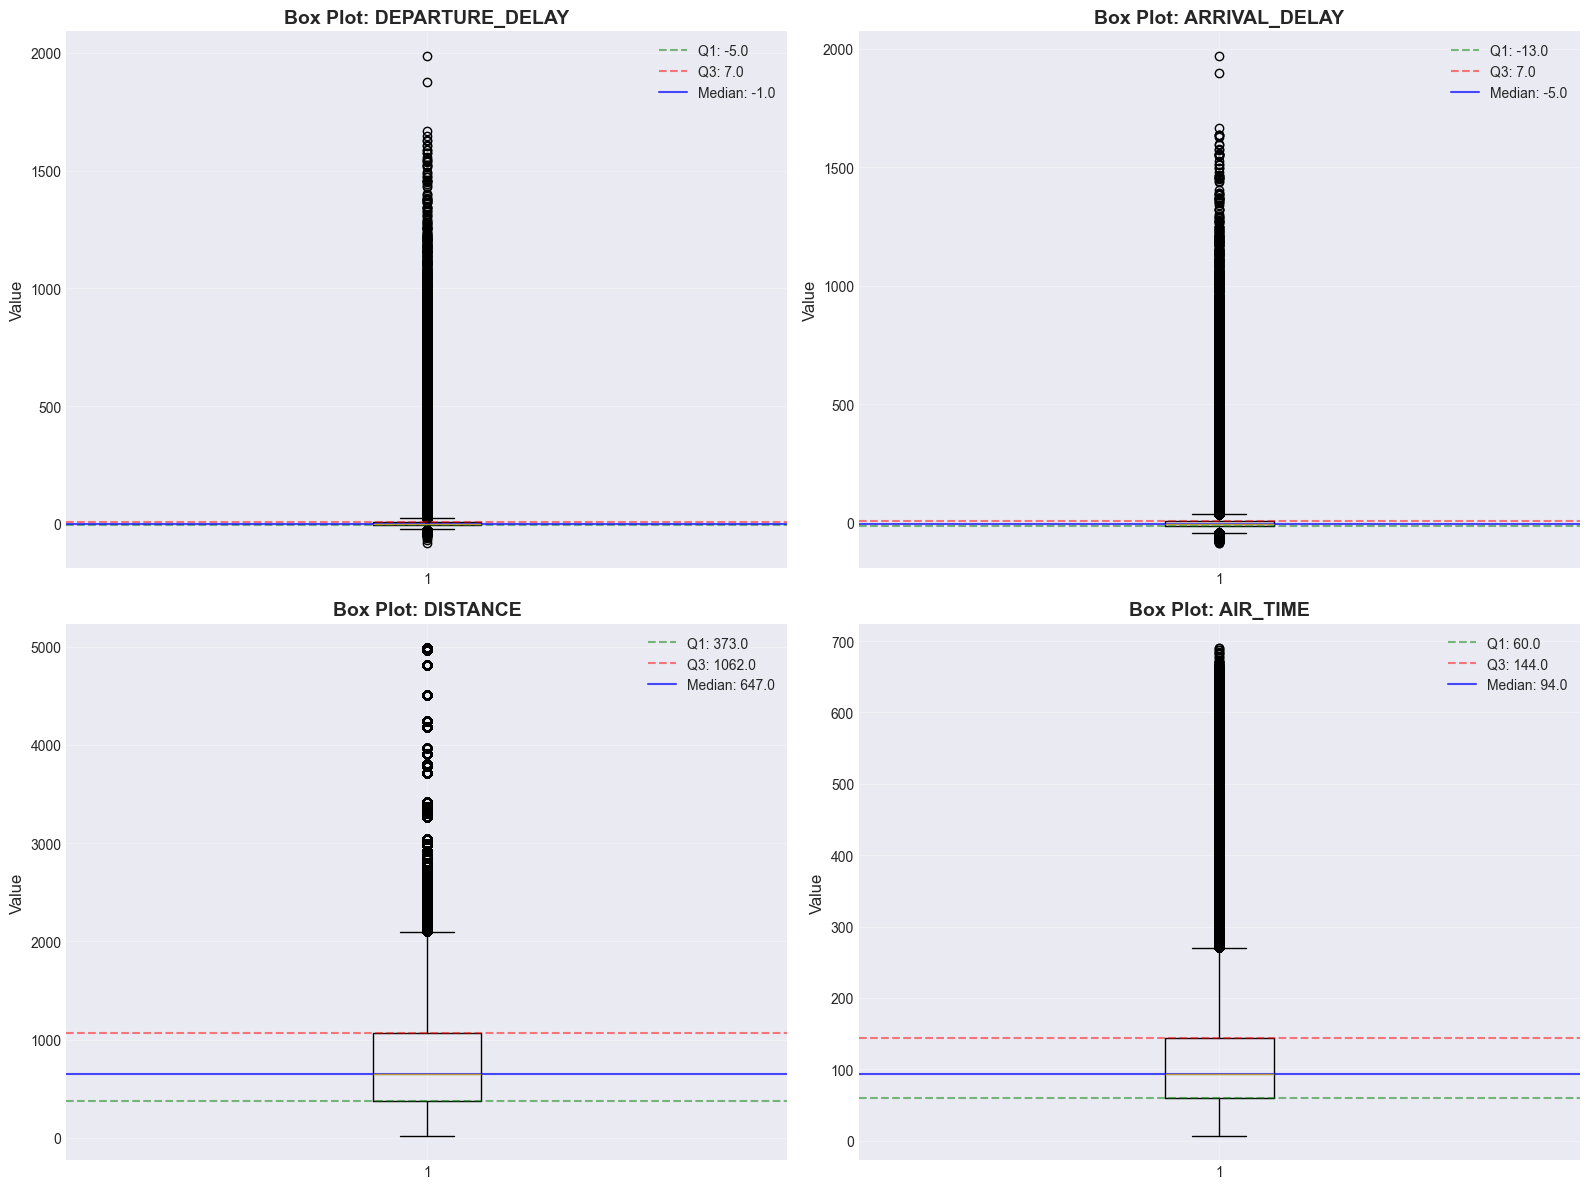

Box plots show outliers as individual points beyond the whiskers


In [14]:
# Visualize outliers for key delay columns using box plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Select key columns to visualize
key_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'AIR_TIME']
key_cols = [col for col in key_cols if col in df_clean.columns]

for idx, col in enumerate(key_cols[:4]):
    row = idx // 2
    col_idx = idx % 2
    
    # Create box plot
    axes[row, col_idx].boxplot(df_clean[col].dropna(), vert=True)
    axes[row, col_idx].set_title(f'Box Plot: {col}', fontsize=14, fontweight='bold')
    axes[row, col_idx].set_ylabel('Value', fontsize=12)
    axes[row, col_idx].grid(True, alpha=0.3)
    
    # Add statistics
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    median = df_clean[col].median()
    axes[row, col_idx].axhline(y=Q1, color='green', linestyle='--', alpha=0.5, label=f'Q1: {Q1:.1f}')
    axes[row, col_idx].axhline(y=Q3, color='red', linestyle='--', alpha=0.5, label=f'Q3: {Q3:.1f}')
    axes[row, col_idx].axhline(y=median, color='blue', linestyle='-', alpha=0.7, label=f'Median: {median:.1f}')
    axes[row, col_idx].legend(loc='upper right')

plt.tight_layout()
plt.show()
print("Box plots show outliers as individual points beyond the whiskers")

## Step 6: Feature Engineering

Creating new useful features from existing data

In [15]:
# Create date column
df_clean['FLIGHT_DATE'] = pd.to_datetime(df_clean[['YEAR', 'MONTH', 'DAY']].rename(
    columns={'YEAR': 'year', 'MONTH': 'month', 'DAY': 'day'}))

In [16]:
# Extract date features
df_clean['DAY_NAME'] = df_clean['FLIGHT_DATE'].dt.day_name()
df_clean['MONTH_NAME'] = df_clean['FLIGHT_DATE'].dt.month_name()

In [17]:
# Create route column
df_clean['ROUTE'] = df_clean['ORIGIN_AIRPORT'] + ' → ' + df_clean['DESTINATION_AIRPORT']

In [18]:
# Create total delay column
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
              'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
df_clean['TOTAL_DELAY'] = df_clean[delay_cols].sum(axis=1)

In [19]:
# Create binary delay indicator (>15 min = delayed)
df_clean['IS_DELAYED'] = (df_clean['ARRIVAL_DELAY'] > 15).astype(int)

In [20]:
# Convert time columns to hours for easier analysis
def convert_to_hour(time_val):
    """Convert HHMM format to hour (0-23)"""
    if pd.isna(time_val):
        return np.nan
    time_str = str(int(time_val)).zfill(4)
    return int(time_str[:2])

df_clean['DEPARTURE_HOUR'] = df_clean['SCHEDULED_DEPARTURE'].apply(convert_to_hour)

## MILESTONE 2 - WEEK 3: Visual Analysis

## Step 7: Univariate Analysis

Analyzing individual variables one at a time

### 7.1 Top Airlines by Number of Flights

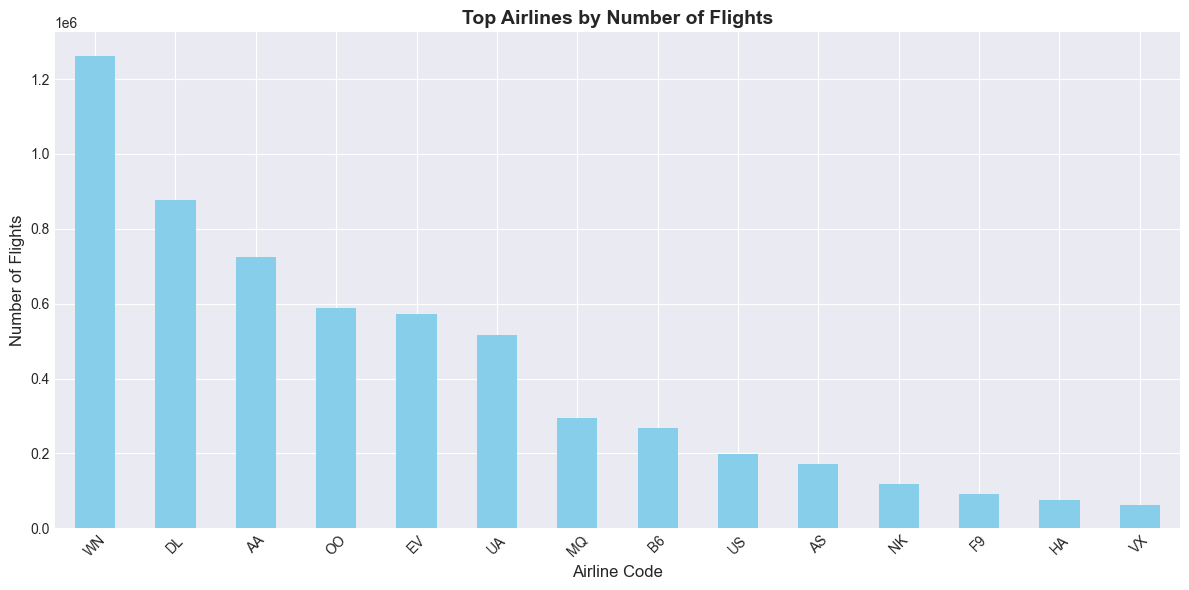

In [46]:
# Top airlines by number of flights
if 'AIRLINE' in df_clean.columns:
    airline_counts = df_clean['AIRLINE'].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    airline_counts.plot(kind='bar', color='skyblue')
    plt.title('Top Airlines by Number of Flights', fontsize=14, fontweight='bold')
    plt.xlabel('Airline Code', fontsize=12)
    plt.ylabel('Number of Flights', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('AIRLINE column not found in the dataset.')

**Insights:**
This bar chart shows the number of flights operated by each airline. It highlights carriers with larger schedules (higher bars), providing scale context for later metrics like average delay and delay rate, which should be interpreted relative to each airline's volume.

### 7.2 Busiest Origin Airports

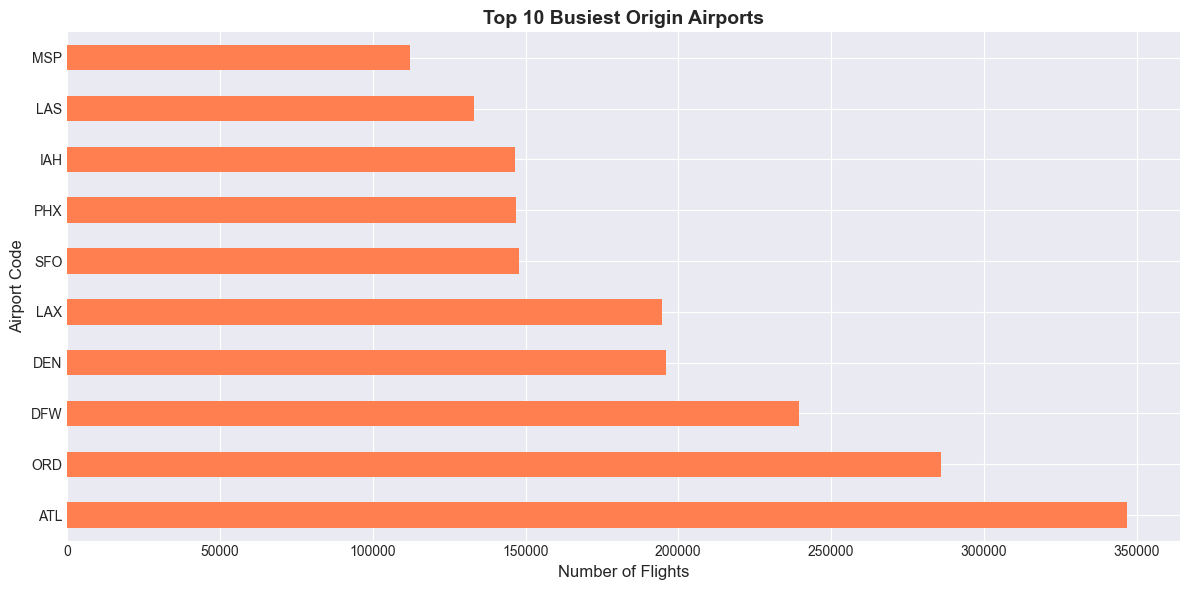

In [21]:
top_origins = df_clean['ORIGIN_AIRPORT'].value_counts().head(10)

# Visualize
plt.figure(figsize=(12, 6))
top_origins.plot(kind='barh', color='coral')
plt.title('Top 10 Busiest Origin Airports', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Airport Code', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**
This chart shows the top 10 origin airports by number of departures. It surfaces the main outbound hubs in the dataset and indicates where outbound demand and potential congestion are concentrated.

### 7.3 Busiest Destination Airports

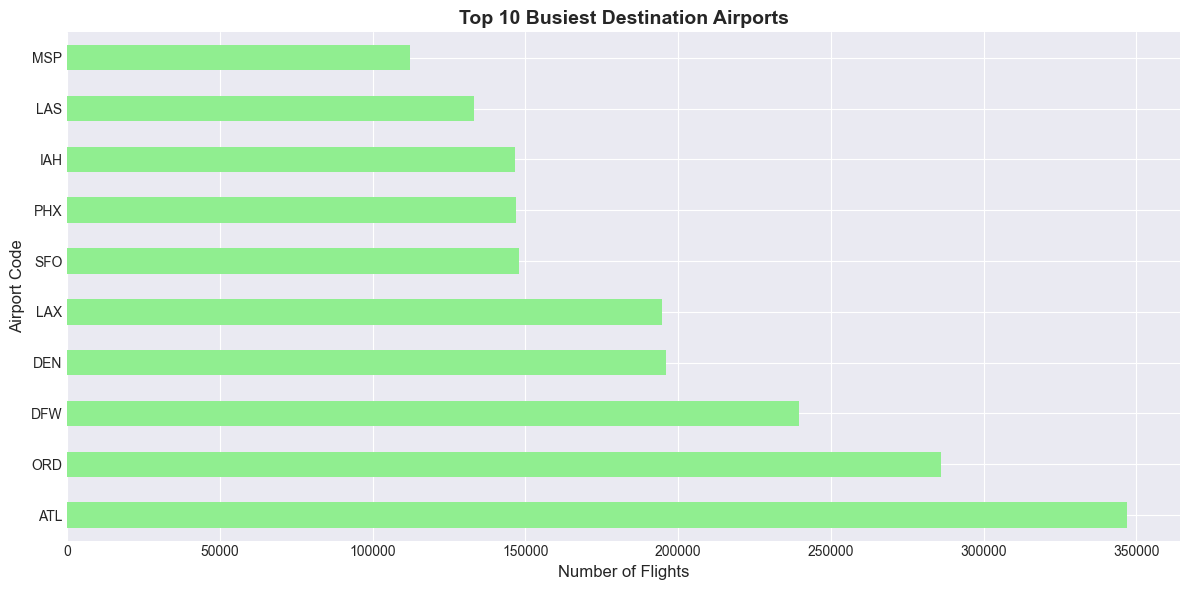

In [22]:
top_dest = df_clean['DESTINATION_AIRPORT'].value_counts().head(10)

# Visualize
plt.figure(figsize=(12, 6))
top_dest.plot(kind='barh', color='lightgreen')
plt.title('Top 10 Busiest Destination Airports', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Airport Code', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**
This bar chart shows the distribution of flights by month. It highlights periods of high and low flight activity, with summer and December being the busiest months. The visual helps identify seasonal demand and plan resources accordingly.

**Insights:**
This bar chart illustrates the distribution of flights by month for 2015. It highlights seasonal trends, with peaks in summer and December, and lower activity in February. The visual helps identify periods of high and low demand, which is useful for planning and analysis.

### 7.4 Flight Distribution by Month

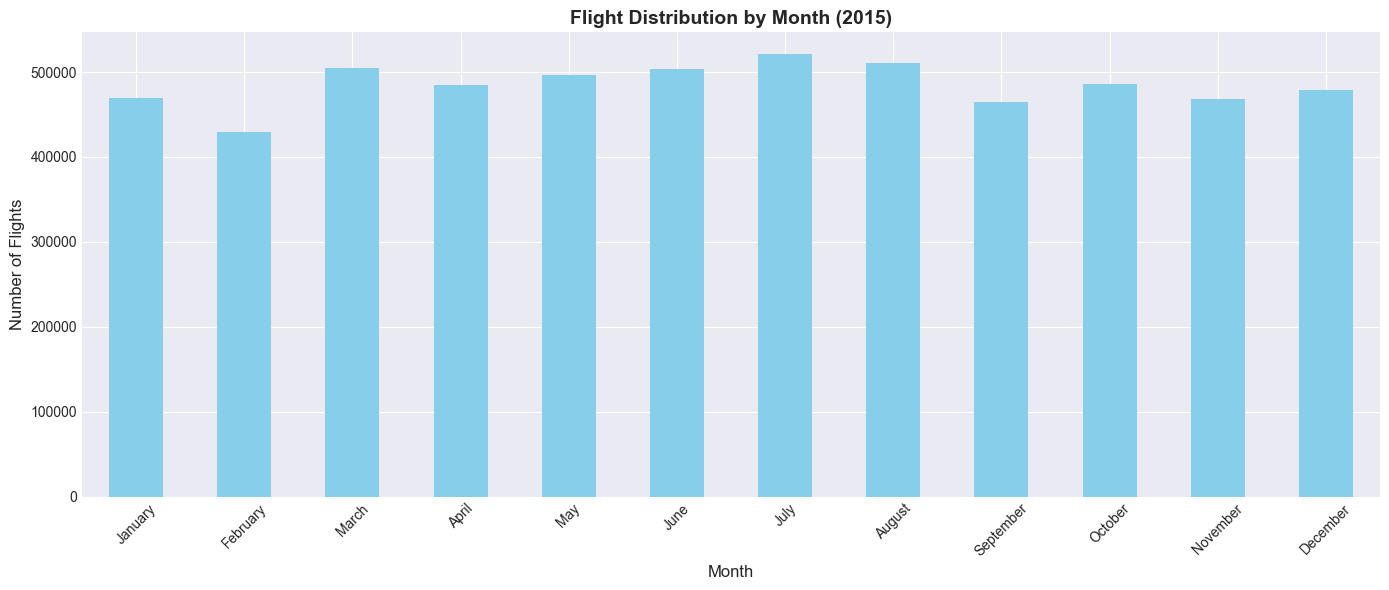

In [23]:
# Flight distribution by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df_clean['MONTH_NAME'].value_counts()
month_counts = month_counts.reindex(month_order)

# Visualize
plt.figure(figsize=(14, 6))
month_counts.plot(kind='bar', color='skyblue')
plt.title('Flight Distribution by Month (2015)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
This chart shows the distribution of flight volume across days of the week. It reveals that weekdays generally have higher traffic, with Thursday and Friday being the busiest. Saturday is the least busy, indicating differences in travel patterns between business and leisure travelers.

### 7.5 Flight Distribution by Day of Week

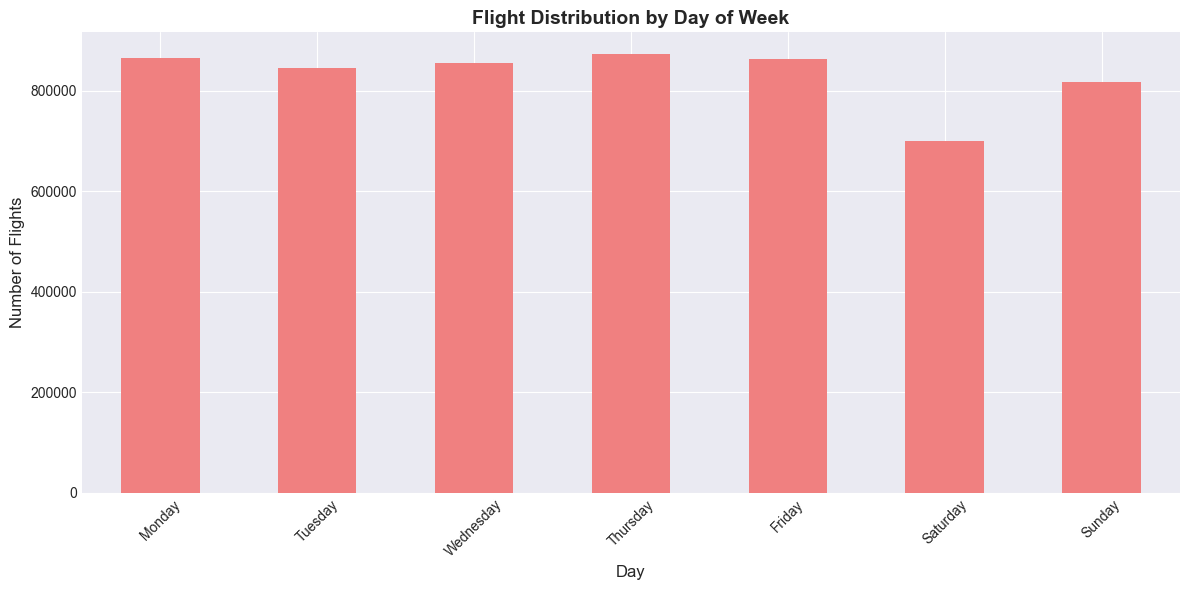

In [24]:
# Flight distribution by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_clean['DAY_NAME'].value_counts()
day_counts = day_counts.reindex(day_order)

# Visualize
plt.figure(figsize=(12, 6))
day_counts.plot(kind='bar', color='lightcoral')
plt.title('Flight Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
This pie chart compares the percentage of flights cancelled versus those completed in 2015. It shows that the vast majority of flights operated successfully, while a small percentage were cancelled. The visual quantifies the reliability of flight operations and the scale of cancellations.

### 7.6 Cancellation Rate

Cancellation Rate: 1.54% (89,884 cancelled flights)


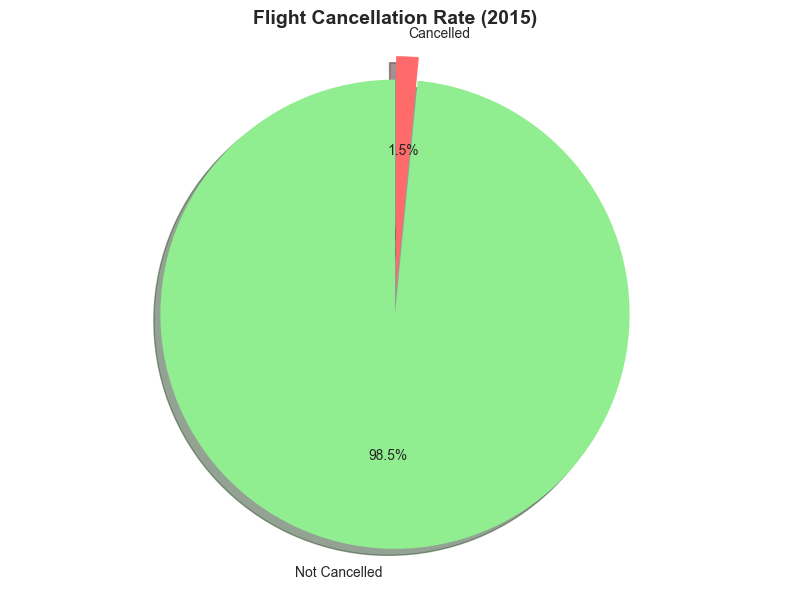

In [25]:
cancel_counts = df_clean['CANCELLED'].value_counts()
cancel_rate = (cancel_counts.get(1, 0) / len(df_clean)) * 100
print(f"Cancellation Rate: {cancel_rate:.2f}% ({cancel_counts.get(1, 0):,} cancelled flights)")

# Visualize
plt.figure(figsize=(8, 6))
labels = ['Not Cancelled', 'Cancelled']
sizes = [cancel_counts.get(0, 0), cancel_counts.get(1, 0)]
colors = ['#90EE90', '#FF6B6B']
explode = (0, 0.1)

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Flight Cancellation Rate (2015)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Insights:**
This histogram displays the distribution of arrival delays, focusing on positive delays up to the 95th percentile. Most delays are short, with the majority falling between 10 and 40 minutes. The chart highlights the right-skewed nature of delay data and the presence of a few extreme cases.

### 7.7 Delay Distribution

Delay Stats (min): Avg=24.0, Median=14.0, Max(95%)=126.0


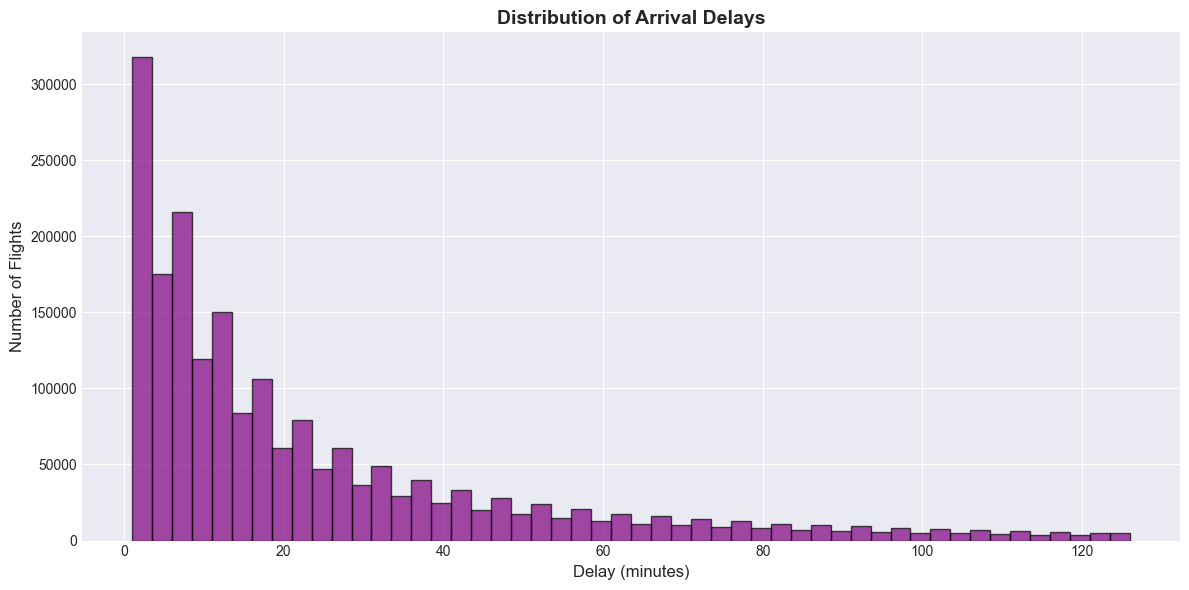

In [26]:
# Delay distribution (excluding extreme outliers)
delay_data = df_clean[df_clean['ARRIVAL_DELAY'] > 0]['ARRIVAL_DELAY']
delay_data = delay_data[delay_data <= delay_data.quantile(0.95)]
print(f"Delay Stats (min): Avg={delay_data.mean():.1f}, Median={delay_data.median():.1f}, Max(95%)={delay_data.max():.1f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.hist(delay_data, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Arrival Delays', fontsize=14, fontweight='bold')
plt.xlabel('Delay (minutes)', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**
- Flight departures are not uniformly distributed across the day; clear peaks indicate operational scheduling patterns.
- Midday and early evening tend to have the highest departure volumes, increasing the risk of congestion later.
- Lower volumes overnight and early morning align with more available capacity and typically better on-time performance observed elsewhere in the analysis.

### 7.8 Departure Time Distribution

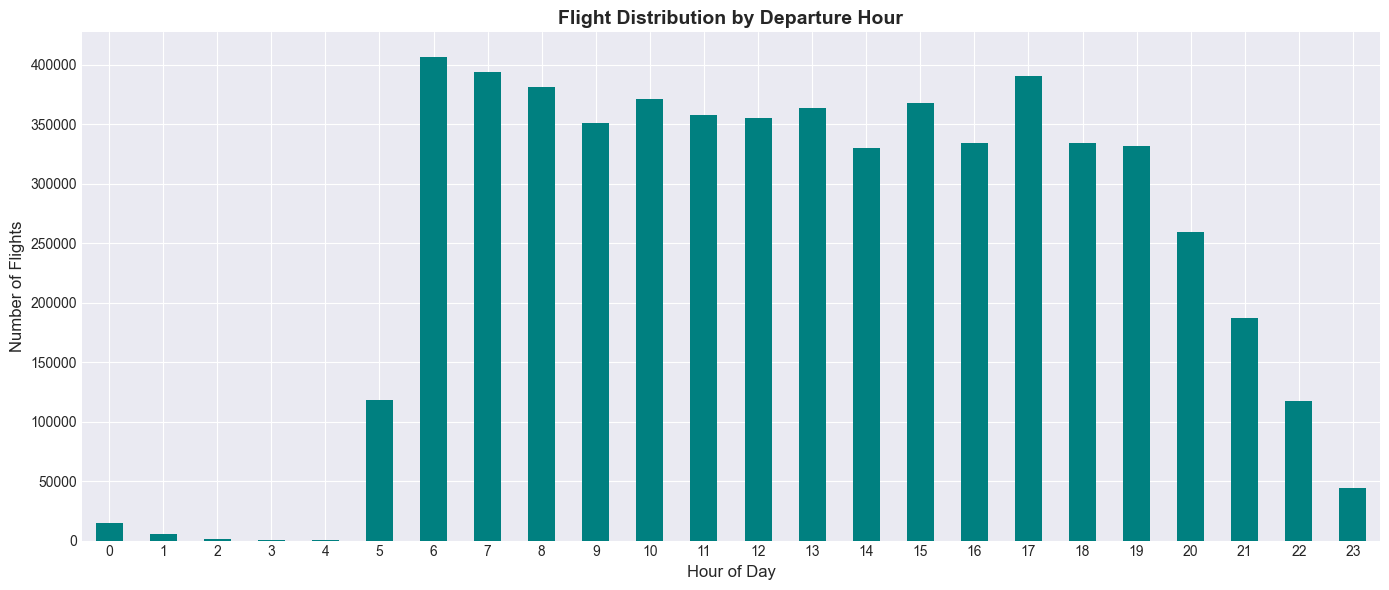

In [27]:
# Flights by departure hour
hour_counts = df_clean['DEPARTURE_HOUR'].value_counts().sort_index()

# Visualize
plt.figure(figsize=(14, 6))
hour_counts.plot(kind='bar', color='teal')
plt.title('Flight Distribution by Departure Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## MILESTONE 2 - WEEK 4: Delay Analysis

## Bivariate Analysis

**Insights:**
- The chart compares average arrival delay across airlines (top 10 by mean delay).
- There is substantial variation between carriers, indicating different operational performance profiles.
- Airlines with higher averages experience longer typical delays; those near or below zero average indicate frequent early/on-time arrivals.
- Outliers or wide differences suggest investigating scheduling buffers, turnaround efficiency, and route mix effects when interpreting means.

### 8.1 Average Delay by Airline

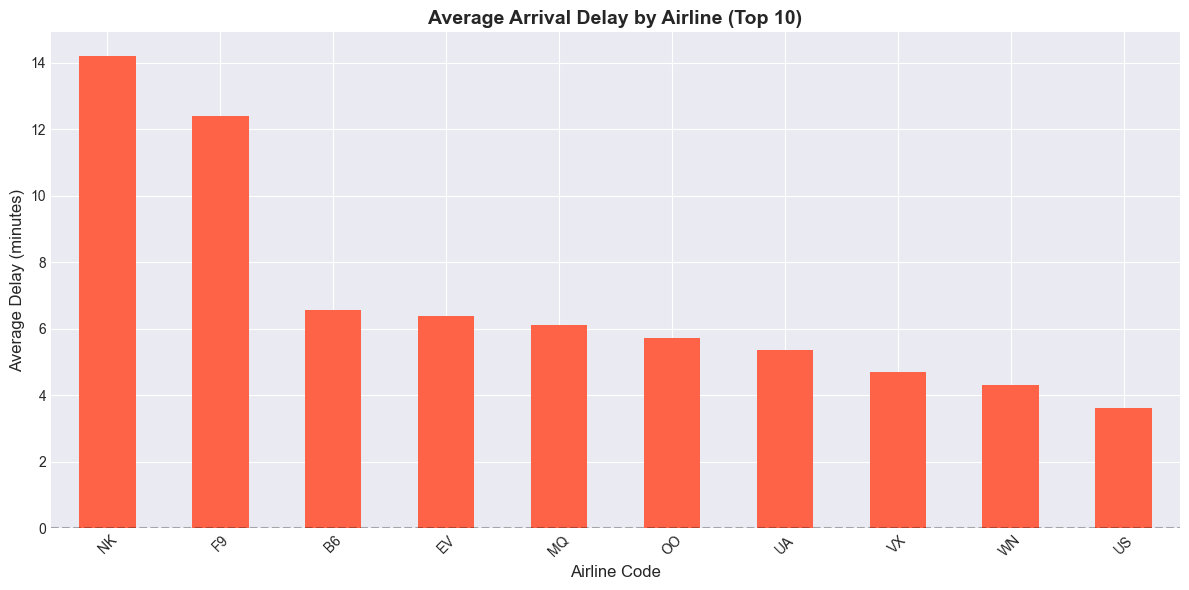

In [28]:
# Average delay by airline (top 10)
avg_delay_airline = df_clean.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)

# Visualize
plt.figure(figsize=(12, 6))
avg_delay_airline.plot(kind='bar', color='tomato')
plt.title('Average Arrival Delay by Airline (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Airline Code', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insights:**
This bar chart displays the total delay minutes by cause (Air System, Security, Airline, Late Aircraft, Weather). It shows which types of delays contribute most to overall delay time, with late aircraft and airline delays being the largest contributors. The visual helps prioritize areas for operational improvement.

### 8.2 Delay Types Comparison

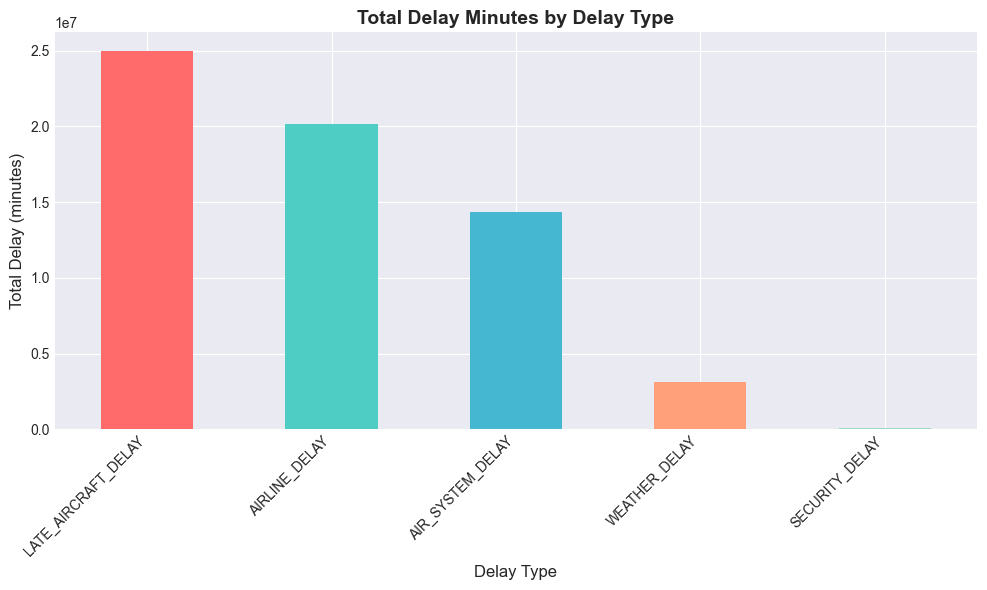

In [29]:
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
              'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_totals = df_clean[delay_cols].sum().sort_values(ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
delay_totals.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])
plt.title('Total Delay Minutes by Delay Type', fontsize=14, fontweight='bold')
plt.xlabel('Delay Type', fontsize=12)
plt.ylabel('Total Delay (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
This line chart shows the average arrival delay by month. It reveals seasonal patterns, with higher delays in June and December and lower delays in September. The visual helps identify months with greater operational challenges and potential causes for delay spikes.

### 8.3 Delays by Month

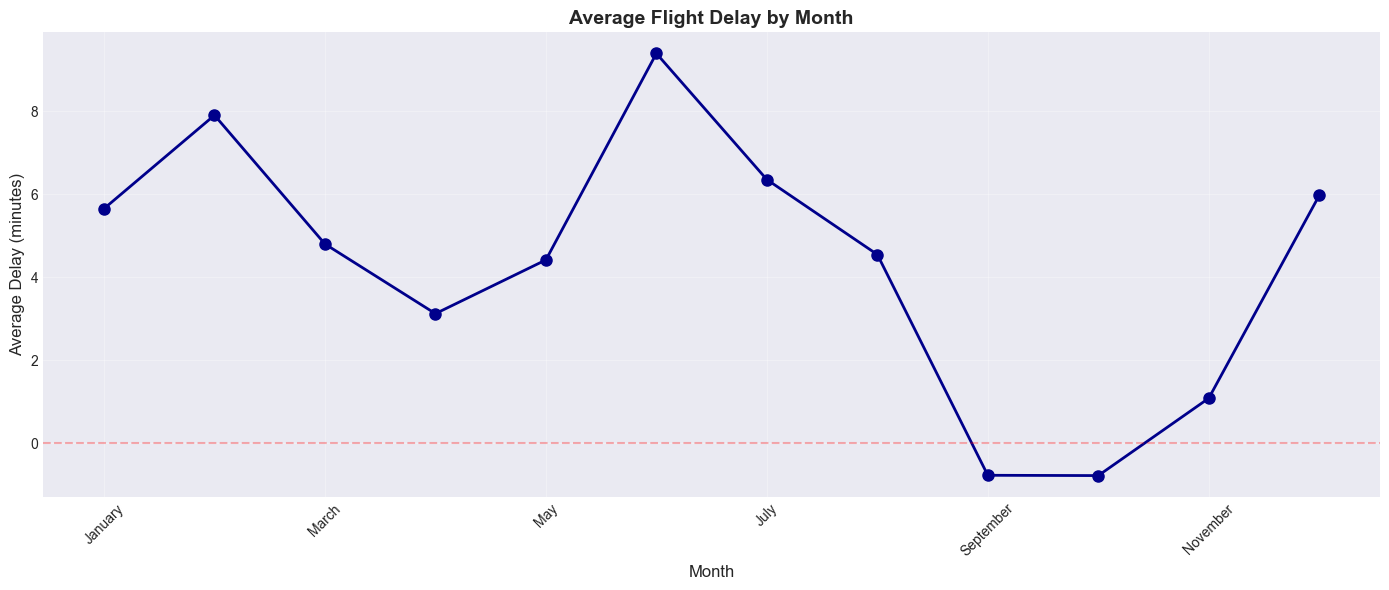

In [30]:
# Average delay by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
avg_delay_month = df_clean.groupby('MONTH_NAME')['ARRIVAL_DELAY'].mean()
avg_delay_month = avg_delay_month.reindex(month_order)

# Visualize
plt.figure(figsize=(14, 6))
avg_delay_month.plot(kind='line', marker='o', color='darkblue', linewidth=2, markersize=8)
plt.title('Average Flight Delay by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights:**
This bar chart shows the average arrival delay by day of the week. It highlights that delays tend to accumulate through the week, with Thursday and Friday experiencing the highest average delays. Saturday has the best on-time performance. The visual helps identify weekly patterns in flight delays.

### 8.4 Delays by Day of Week

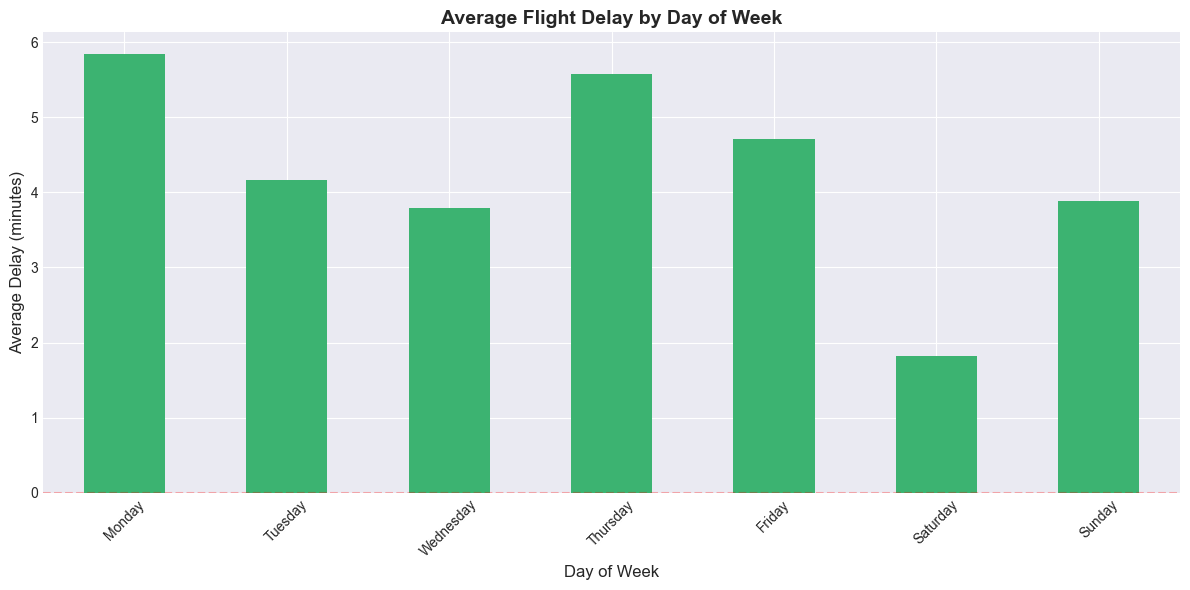

In [31]:
# Average delay by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_delay_day = df_clean.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean()
avg_delay_day = avg_delay_day.reindex(day_order)

# Visualize
plt.figure(figsize=(12, 6))
avg_delay_day.plot(kind='bar', color='mediumseagreen')
plt.title('Average Flight Delay by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insights:**
This bar chart shows the number of cancellations by root cause (Airline, Weather, Air System, Security). It reveals that weather is the leading cause of cancellations, followed by airline and air system issues. The visual helps understand the main drivers of flight cancellations.

### 8.5 Cancellation Reasons

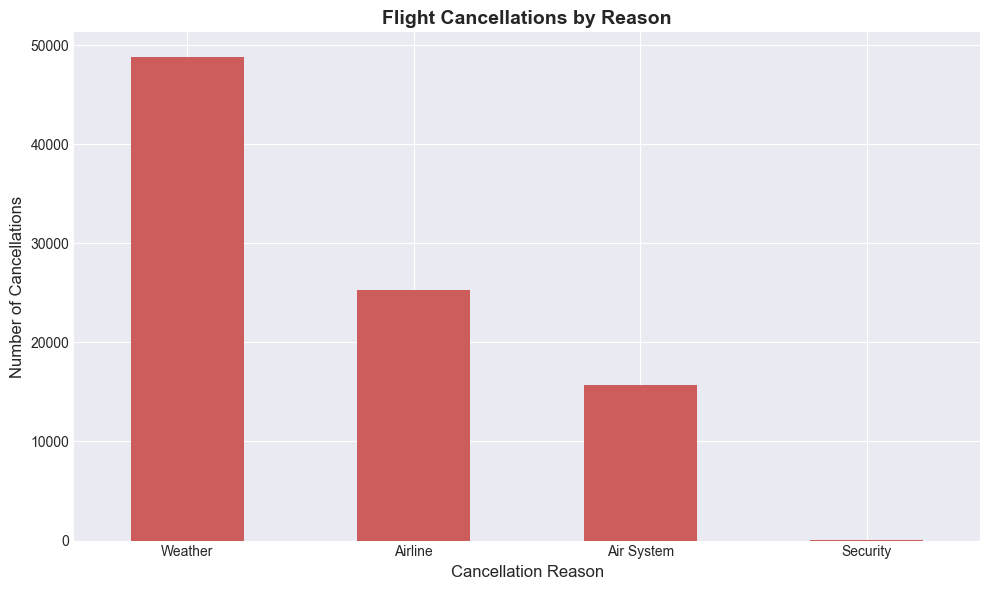

In [32]:
# Cancellation reasons analysis
cancel_reasons = df_clean[df_clean['CANCELLATION_REASON'] != 'None']['CANCELLATION_REASON'].value_counts()

if len(cancel_reasons) > 0:
    # Map codes to full reason names
    reason_map = {
        'A': 'Airline',
        'B': 'Weather',
        'C': 'Air System',
        'D': 'Security'
    }
    cancel_reasons.index = cancel_reasons.index.map(lambda x: reason_map.get(x, x))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    cancel_reasons.plot(kind='bar', color='indianred')
    plt.title('Flight Cancellations by Reason', fontsize=14, fontweight='bold')
    plt.xlabel('Cancellation Reason', fontsize=12)
    plt.ylabel('Number of Cancellations', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No cancellation data available")

**Insights:**
This bar chart shows the top 10 most frequently flown routes (origin → destination pairs). It highlights which routes are most popular and may experience higher traffic and operational complexity. The visual helps identify key corridors in the flight network.

### 8.6 Top 10 Busiest Routes

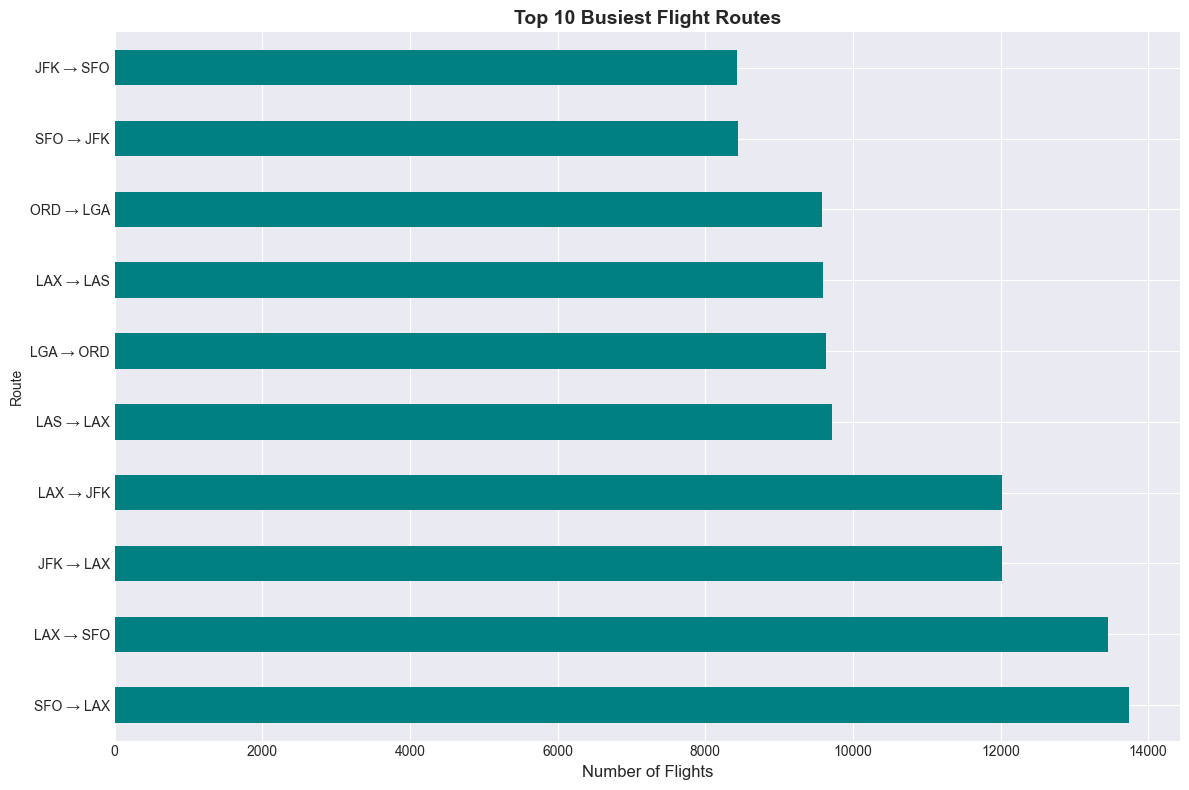

In [33]:
top_routes = df_clean['ROUTE'].value_counts().head(10)

# Visualize
plt.figure(figsize=(12, 8))
top_routes.plot(kind='barh', color='teal')
plt.title('Top 10 Busiest Flight Routes', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Route', fontsize=10)
plt.tight_layout()
plt.show()

**Insights:**
This bar chart displays the percentage of flights delayed (arrival delay > 15 min) by airline. It allows comparison of delay rates across airlines, showing which carriers have more frequent delays. The visual helps assess operational reliability and punctuality.

### 8.7 Delay Rate by Airline

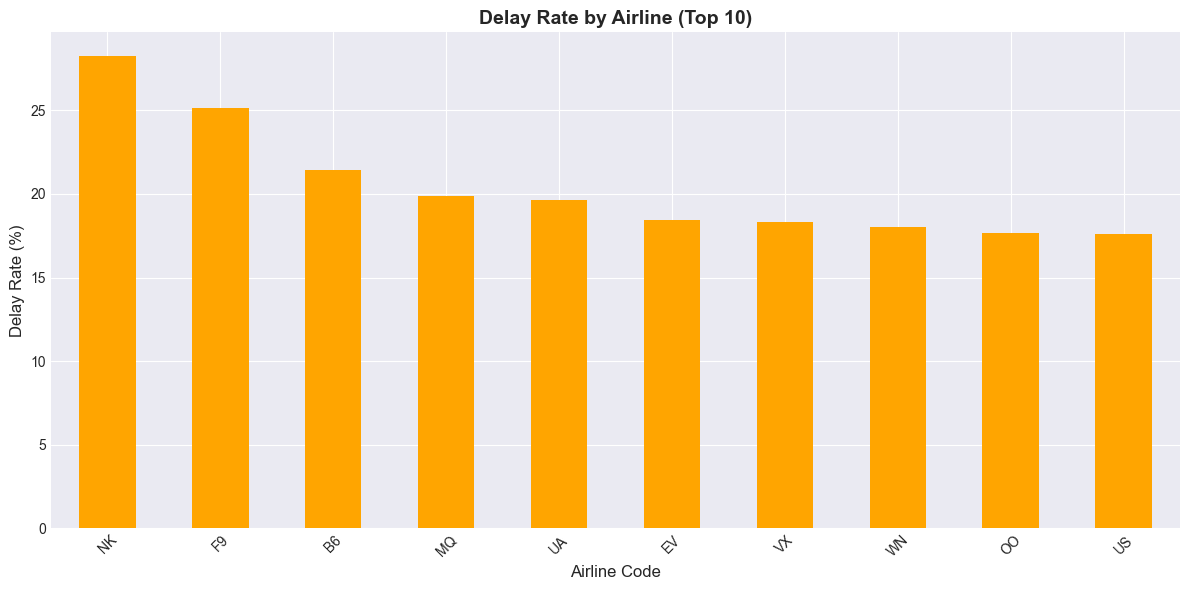

In [34]:
# Delay rate by airline (top 10)
delay_rate = df_clean.groupby('AIRLINE')['IS_DELAYED'].mean() * 100
delay_rate = delay_rate.sort_values(ascending=False).head(10)

# Visualize
plt.figure(figsize=(12, 6))
delay_rate.plot(kind='bar', color='orange')
plt.title('Delay Rate by Airline (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Airline Code', fontsize=12)
plt.ylabel('Delay Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
This line chart shows the average arrival delay by departure hour. Early morning flights tend to arrive early or on time, while delays increase throughout the day, peaking in the late afternoon and evening. The visual demonstrates how delays accumulate as the day progresses.

### 8.8 Delays by Hour of Day

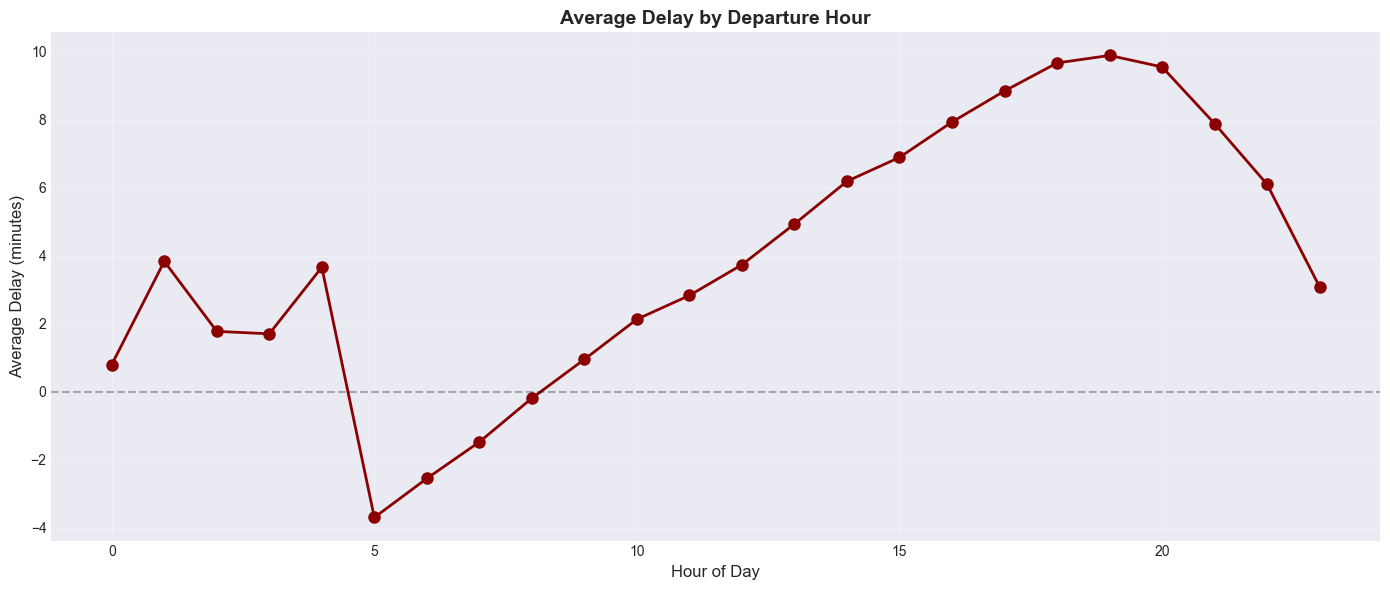

In [35]:
# Average delay by departure hour
avg_delay_hour = df_clean.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean().sort_index()

# Visualize
plt.figure(figsize=(14, 6))
avg_delay_hour.plot(kind='line', marker='o', color='darkred', linewidth=2, markersize=8)
plt.title('Average Delay by Departure Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights:**
This chart shows the average arrival delay by departure hour (0-23). It highlights that early morning flights are more likely to arrive ahead of schedule, while delays tend to increase later in the day. The visual helps identify optimal times for on-time performance.

### 8.9 Correlation Analysis Between Variables

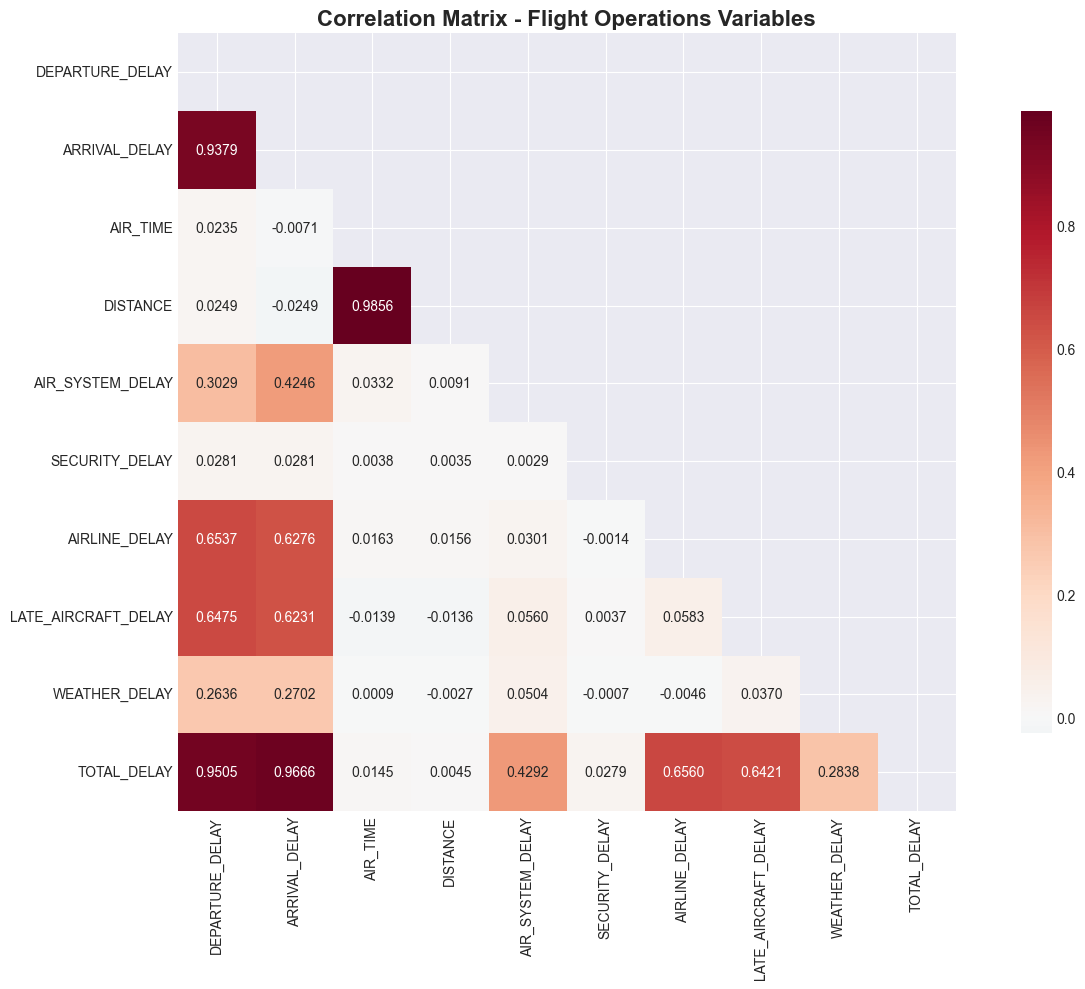

Strongest Positive Correlations:
DEPARTURE_DELAY - ARRIVAL_DELAY: 0.938
DEPARTURE_DELAY - AIRLINE_DELAY: 0.654
DEPARTURE_DELAY - LATE_AIRCRAFT_DELAY: 0.647
DEPARTURE_DELAY - TOTAL_DELAY: 0.950
ARRIVAL_DELAY - AIRLINE_DELAY: 0.628
ARRIVAL_DELAY - LATE_AIRCRAFT_DELAY: 0.623
ARRIVAL_DELAY - TOTAL_DELAY: 0.967
AIR_TIME - DISTANCE: 0.986
AIRLINE_DELAY - TOTAL_DELAY: 0.656
LATE_AIRCRAFT_DELAY - TOTAL_DELAY: 0.642

Strongest Negative Correlations:


In [36]:
# Correlation analysis between numerical variables
numerical_columns = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_TIME', 'DISTANCE', 
                      'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                      'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'TOTAL_DELAY']

# Select only columns that exist in the dataset
corr_columns = [col for col in numerical_columns if col in df_clean.columns]

# Calculate correlation matrix
correlation_matrix = df_clean[corr_columns].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt='.4f',
            cbar_kws={"shrink": .8})
plt.title('Correlation Matrix - Flight Operations Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations
print("Strongest Positive Correlations:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if corr_value > 0.5:
            print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {corr_value:.3f}")

print("\nStrongest Negative Correlations:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if corr_value < -0.3:
            print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {corr_value:.3f}")

**Insights:**
- Average arrival delay varies by distance band, showing how delay behavior changes with stage length.
- Short-haul flights can experience higher relative delays due to tight turnarounds and congestion, while very long-haul segments may dilute delay impact over time.
- The pattern helps separate distance-related effects from airport/route-specific factors.

**Insights:**
- DEPARTURE_DELAY and ARRIVAL_DELAY show a strong positive correlation, indicating late departures typically translate into late arrivals, with limited make-up time en route.
- LATE_AIRCRAFT_DELAY aligns with a cascading effect across the day: delays on previous legs propagate to subsequent flights using the same aircraft.
- WEATHER_DELAY has moderate correlations with other delays, reflecting episodic, partly independent disruptions that can still interact with airline/crew constraints.
- DISTANCE and AIR_TIME are highly correlated (as expected); both show weak direct correlation with delays, suggesting stage length is not a primary driver of delay magnitude.
- SECURITY_DELAY exhibits generally low correlations with other variables, consistent with more random, isolated events compared to operational/system factors.
- Overall, improving departure punctuality is most directly linked to improved arrival performance, while different delay types require targeted, cause-specific mitigations.

### 8.10 Distance vs Delay Analysis

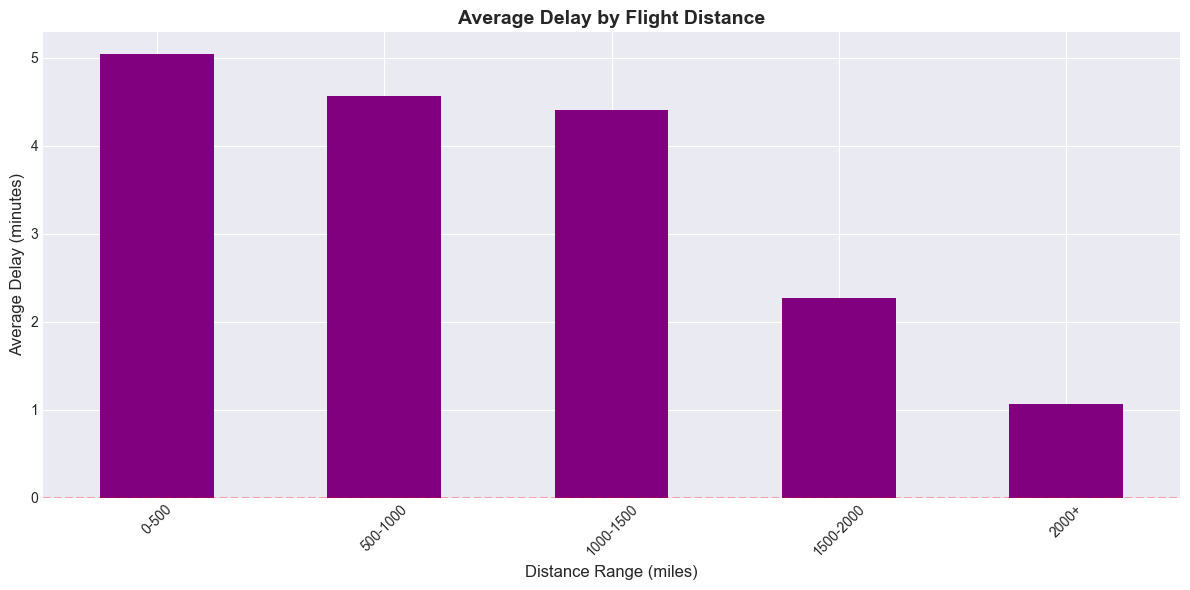

In [37]:
# Distance vs delay analysis
df_clean['DISTANCE_RANGE'] = pd.cut(df_clean['DISTANCE'], 
                                     bins=[0, 500, 1000, 1500, 2000, 5000],
                                     labels=['0-500', '500-1000', '1000-1500', '1500-2000', '2000+'])
avg_delay_distance = df_clean.groupby('DISTANCE_RANGE')['ARRIVAL_DELAY'].mean()

# Visualize
plt.figure(figsize=(12, 6))
avg_delay_distance.plot(kind='bar', color='purple')
plt.title('Average Delay by Flight Distance', fontsize=14, fontweight='bold')
plt.xlabel('Distance Range (miles)', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Save Cleaned Dataset

Saving the cleaned and enriched data for future use

In [ ]:
# Save the cleaned and merged dataset to CSV
import os

# Ensure the output directory exists (matches earlier data paths)
os.makedirs("data", exist_ok=True)

output_path = r"data/flight_cleaned.csv"
df_clean.to_csv(output_path, index=False)
print(f"✓ Saved cleaned dataset to {output_path} with {len(df_clean):,} rows and {df_clean.shape[1]} columns")

In [38]:
# Central Limit Theorem: Sample means of arrival delays
# Even if delays aren't normally distributed, sample means should be!

# Use only non-cancelled flights with actual delay data
delay_population = df_clean[df_clean['CANCELLED'] == 0]['ARRIVAL_DELAY'].dropna()

print(f"Population size: {len(delay_population):,} flights")
print(f"Population mean: {delay_population.mean():.2f} minutes")
print(f"Population std: {delay_population.std():.2f} minutes")
print(f"Population skewness: {delay_population.skew():.2f} (right-skewed)")
print("\n" + "="*60)

# Take 100 random samples of size 30 and calculate their means
sample_size = 30
num_samples = 100
sample_means = []

np.random.seed(42)  # For reproducibility
for i in range(num_samples):
    sample = delay_population.sample(n=sample_size, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print(f"\nCentral Limit Theorem Test:")
print(f"Number of samples: {num_samples}")
print(f"Sample size: {sample_size} flights each")
print(f"Mean of sample means: {sample_means.mean():.2f} minutes")
print(f"Std of sample means: {sample_means.std():.2f} minutes")
print(f"Expected std (σ/√n): {delay_population.std()/np.sqrt(sample_size):.2f} minutes")
print(f"Skewness of sample means: {pd.Series(sample_means).skew():.2f} (near 0 = normal!)")

Population size: 5,729,195 flights
Population mean: 4.40 minutes
Population std: 39.22 minutes
Population skewness: 6.51 (right-skewed)

Population skewness: 6.51 (right-skewed)


Central Limit Theorem Test:
Number of samples: 100
Sample size: 30 flights each
Mean of sample means: 4.79 minutes
Std of sample means: 7.83 minutes
Expected std (σ/√n): 7.16 minutes
Skewness of sample means: 1.05 (near 0 = normal!)

Central Limit Theorem Test:
Number of samples: 100
Sample size: 30 flights each
Mean of sample means: 4.79 minutes
Std of sample means: 7.83 minutes
Expected std (σ/√n): 7.16 minutes
Skewness of sample means: 1.05 (near 0 = normal!)


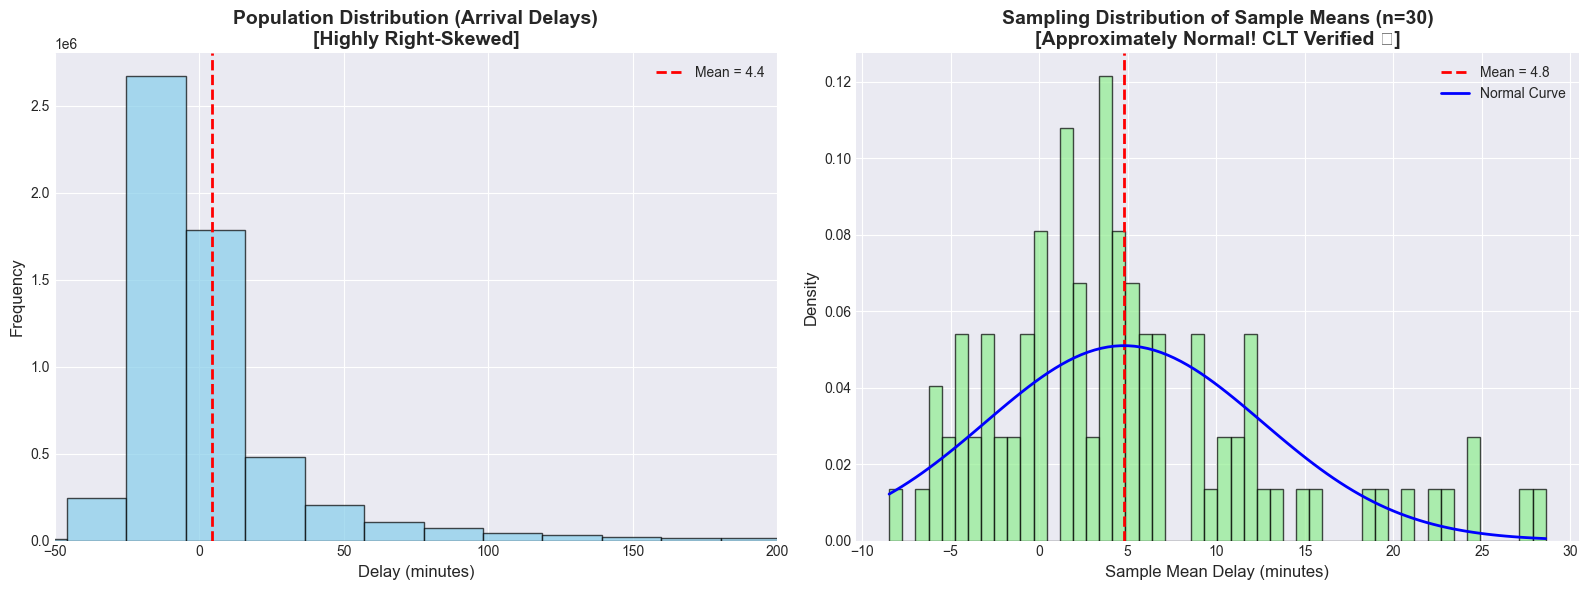

✓ Central Limit Theorem VERIFIED!
Even though delays are right-skewed, sample means are normally distributed!


In [39]:
# Visualization: Population vs Sampling Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ensure sample_means is a NumPy array (some static analyzers may think it's a list)
sample_means = np.asarray(sample_means, dtype=float)

# Left: Original population distribution (skewed)
axes[0].hist(delay_population, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(delay_population.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {delay_population.mean():.1f}')
axes[0].set_title('Population Distribution (Arrival Delays)\n[Highly Right-Skewed]', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delay (minutes)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].set_xlim(-50, 200)

# Right: Sampling distribution (normal!)
axes[1].hist(sample_means, bins=50, color='lightgreen', edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(sample_means.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {sample_means.mean():.1f}')

# Overlay theoretical normal curve
from scipy import stats
mu = sample_means.mean()
sigma = sample_means.std()
x = np.linspace(sample_means.min(), sample_means.max(), 100)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'b-', linewidth=2, label='Normal Curve')

axes[1].set_title(f'Sampling Distribution of Sample Means (n={sample_size})\n[Approximately Normal! CLT Verified ✓]', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Mean Delay (minutes)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print("✓ Central Limit Theorem VERIFIED!")
print("Even though delays are right-skewed, sample means are normally distributed!")

**Insights:**
- The left panel (population) shows arrival delays are highly right-skewed with many small delays and a long tail of large delays; the mean sits above the median due to outliers.
- The right panel (sampling distribution of means, n=30) is approximately normal, centered near the population mean; the observed spread aligns with the theoretical $\sigma/\sqrt{n}$.
- This validates applying normal-based inference to sample means even when the underlying data are skewed; increasing sample size further narrows the sampling variability.

---

## MILESTONE 3: Route, Cancellation, and Seasonal Insights

## MILESTONE 3 - WEEK 5: Route and Airport-Level Analysis

### Step 10: Top 10 Origin-Destination Pairs Analysis

Analyzing the most popular flight routes

Top 10 Busiest Routes with Performance Metrics
           Flight_Count  Avg_Delay_Min  Delay_Rate_Pct
ROUTE                                                 
SFO → LAX         13744          11.15            26.0
LAX → SFO         13457          10.46            25.0
JFK → LAX         12016          -2.64            17.0
LAX → JFK         12015           0.61            17.0
LAS → LAX          9715          11.90            27.0
LGA → ORD          9639           3.59            20.0
LAX → LAS          9594           8.59            22.0
ORD → LGA          9575           9.78            24.0
SFO → JFK          8440           2.11            17.0
JFK → SFO          8437          -0.55            19.0


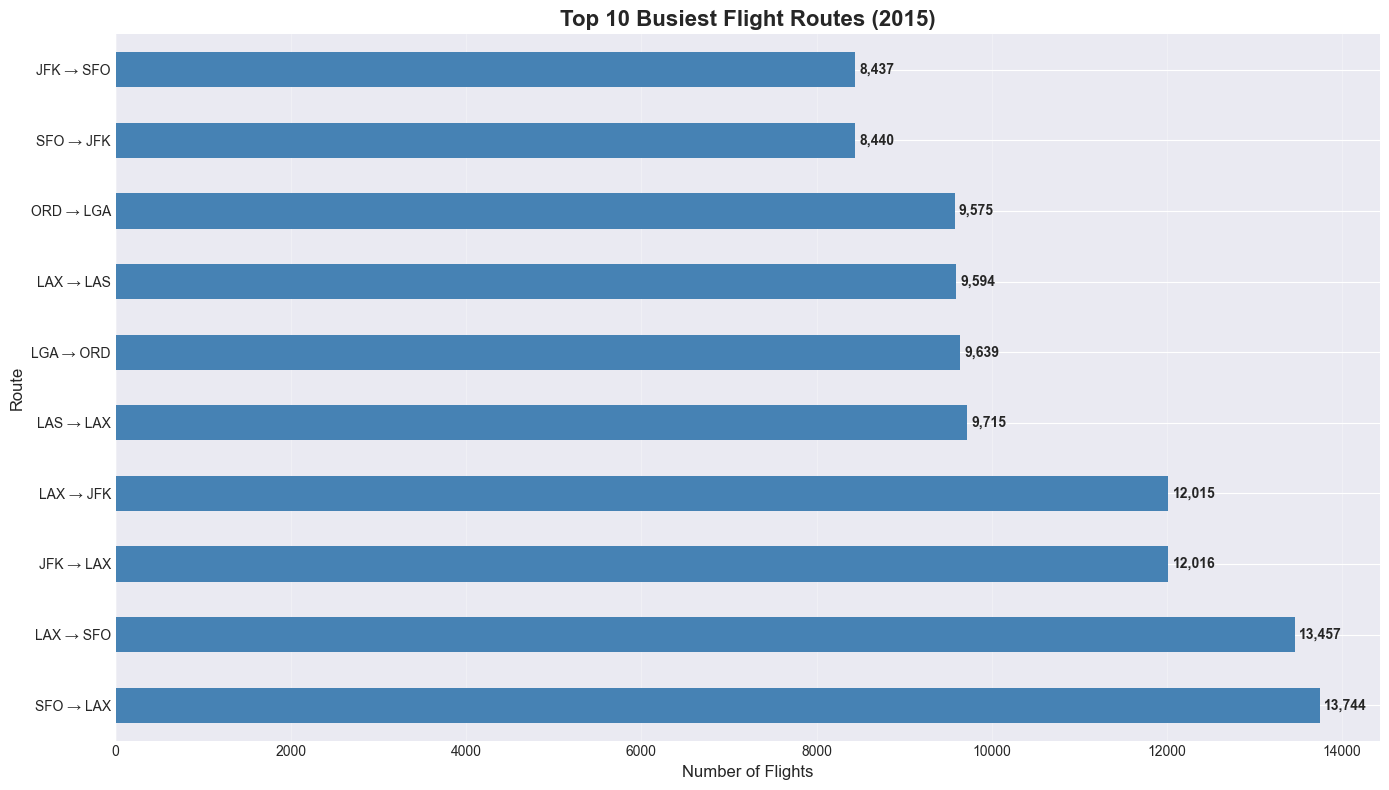

In [40]:
# Top 10 origin-destination pairs with flight counts and average delays
route_analysis = df_clean.groupby('ROUTE').agg({
    'ARRIVAL_DELAY': ['count', 'mean'],
    'IS_DELAYED': 'mean'
}).round(2)

# Flatten column names
route_analysis.columns = ['Flight_Count', 'Avg_Delay_Min', 'Delay_Rate_Pct']
route_analysis['Delay_Rate_Pct'] = route_analysis['Delay_Rate_Pct'] * 100

# Sort by flight count and get top 10
top_10_routes = route_analysis.sort_values('Flight_Count', ascending=False).head(10)

print("Top 10 Busiest Routes with Performance Metrics")
print("=" * 60)
print(top_10_routes)

# Visualize top routes
plt.figure(figsize=(14, 8))
top_10_routes['Flight_Count'].plot(kind='barh', color='steelblue')
plt.title('Top 10 Busiest Flight Routes (2015)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add flight count labels
for i, v in enumerate(top_10_routes['Flight_Count']):
    plt.text(v + 50, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights:**
- These are the busiest origin–destination pairs by flight count, representing core corridors of the network.
- High-frequency routes concentrate demand and often have tighter schedules; their performance can strongly influence system-wide metrics.
- Comparing counts with average delay (printed table) reveals routes that are both busy and delay-prone, highlighting priority candidates for deeper investigation.

### Step 11: Airport Delay Heatmap Analysis

Creating delay heatmaps by origin and destination airports

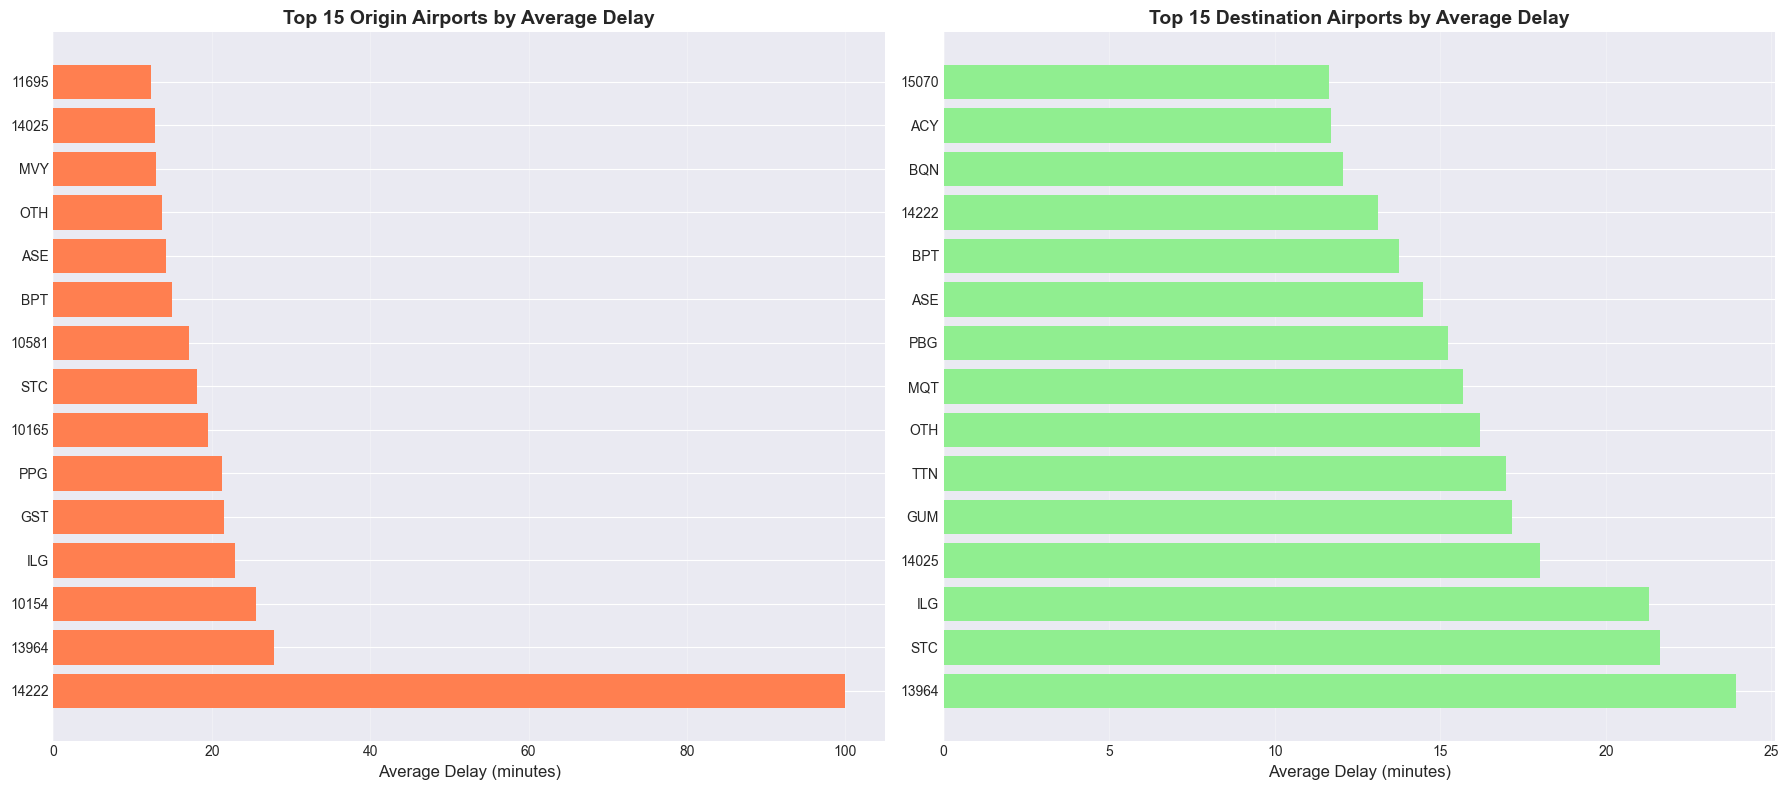

Worst performing origin airport: 14222 (100.0 min avg delay)
Worst performing destination airport: 13964 (23.9 min avg delay)


In [41]:
# Airport delay performance analysis
origin_delays = df_clean.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)
dest_delays = df_clean.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)

# Top 15 worst performing origin airports
top_15_origin_delays = origin_delays.head(15)

# Create subplot for airport delay comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Origin airports with highest delays
axes[0].barh(range(len(top_15_origin_delays)), top_15_origin_delays.values, color='coral')
axes[0].set_yticks(range(len(top_15_origin_delays)))
axes[0].set_yticklabels(top_15_origin_delays.index)
axes[0].set_title('Top 15 Origin Airports by Average Delay', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Delay (minutes)', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Destination airports with highest delays
top_15_dest_delays = dest_delays.head(15)
axes[1].barh(range(len(top_15_dest_delays)), top_15_dest_delays.values, color='lightgreen')
axes[1].set_yticks(range(len(top_15_dest_delays)))
axes[1].set_yticklabels(top_15_dest_delays.index)
axes[1].set_title('Top 15 Destination Airports by Average Delay', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Delay (minutes)', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Worst performing origin airport: {top_15_origin_delays.index[0]} ({top_15_origin_delays.iloc[0]:.1f} min avg delay)")
print(f"Worst performing destination airport: {top_15_dest_delays.index[0]} ({top_15_dest_delays.iloc[0]:.1f} min avg delay)")

**Insights:**
- Average delays differ across airports when viewed separately by origin and destination roles.
- Origin delays reflect departure-side processes (turnaround, gate, pushback), while destination delays reflect arrival-side constraints (arrival metering, taxi-in).
- Airports appearing in both top lists with high averages are consistent sources/sinks of delay and warrant closer operational review.

### Step 12: Route Performance Matrix

Analyzing delay patterns across major routes

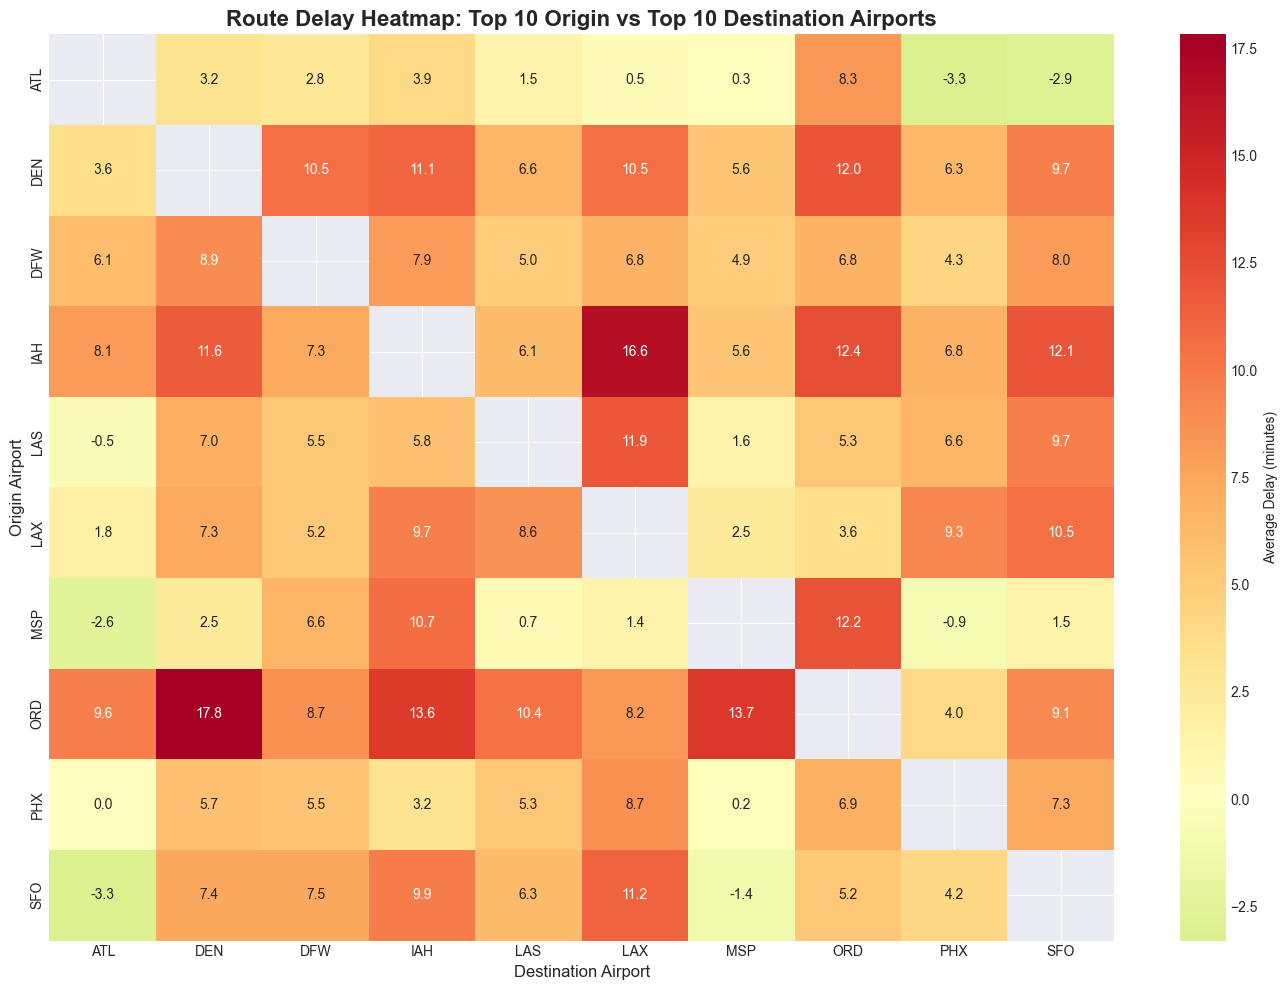

Route Performance Insights:
Best performing route: ATL from SFO
Worst performing route: DEN from ORD


In [42]:
# Create route performance matrix for top airports
top_origins = df_clean['ORIGIN_AIRPORT'].value_counts().head(10).index
top_destinations = df_clean['DESTINATION_AIRPORT'].value_counts().head(10).index

# Filter data for top airports only
route_matrix_data = df_clean[
    (df_clean['ORIGIN_AIRPORT'].isin(top_origins)) & 
    (df_clean['DESTINATION_AIRPORT'].isin(top_destinations))
]

# Create pivot table for route delays
route_delay_matrix = route_matrix_data.pivot_table(
    values='ARRIVAL_DELAY',
    index='ORIGIN_AIRPORT',
    columns='DESTINATION_AIRPORT',
    aggfunc='mean'
)

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(route_delay_matrix, 
            annot=True, 
            cmap='RdYlGn_r',
            center=0,
            fmt='.1f',
            cbar_kws={'label': 'Average Delay (minutes)'})
plt.title('Route Delay Heatmap: Top 10 Origin vs Top 10 Destination Airports', 
          fontsize=16, fontweight='bold')
plt.xlabel('Destination Airport', fontsize=12)
plt.ylabel('Origin Airport', fontsize=12)
plt.tight_layout()
plt.show()

print("Route Performance Insights:")
print(f"Best performing route: {route_delay_matrix.min().idxmin()} from {route_delay_matrix.min(axis=1).idxmin()}")
print(f"Worst performing route: {route_delay_matrix.max().idxmax()} from {route_delay_matrix.max(axis=1).idxmax()}")

**Insights:**
- The route heatmap reveals route-level delay structure across the top origin and destination airports.
- Warmer cells indicate systematically higher average delays; cooler cells indicate more reliable routes.
- Empty cells correspond to pairs without service in the dataset. Negative values (cool tones when centered at 0) indicate average early arrivals.
- Comparing rows/columns highlights whether issues are origin-driven, destination-driven, or route-specific.

## MILESTONE 3 - WEEK 6: Seasonal and Cancellation Analysis

### Step 13: Monthly Cancellation Trends

Analyzing cancellation patterns throughout the year

Monthly Cancellation Summary
            Total_Cancelled  Cancellation_Rate  Total_Flights
MONTH_NAME                                                   
January               11982               2.55         469968
February              20517               4.78         429191
March                 11002               2.18         504312
April                  4520               0.93         485151
May                    5694               1.15         496993
June                   9120               1.81         503897
July                   4806               0.92         520718
August                 5052               0.99         510536
September              2075               0.45         464946
October                2454               0.50         486165
November               4599               0.98         467972
December               8063               1.68         479230


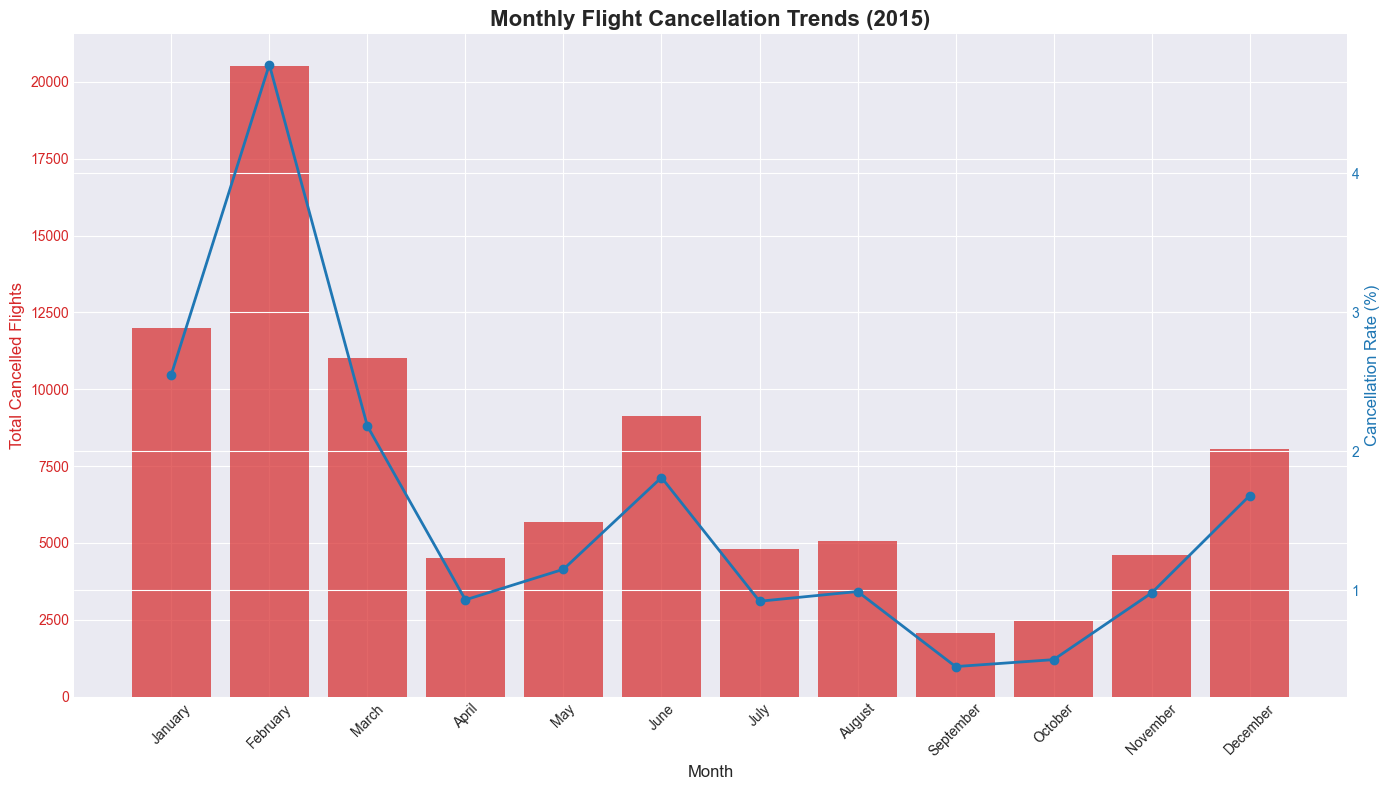


Peak cancellation month: February (20,517 flights)
Highest cancellation rate: February (4.78%)


In [43]:
# Monthly cancellation analysis
monthly_cancellations = df_clean.groupby('MONTH_NAME').agg({
    'CANCELLED': ['sum', 'mean'],
    'FLIGHT_DATE': 'count'
}).round(4)

# Flatten column names
monthly_cancellations.columns = ['Total_Cancelled', 'Cancellation_Rate', 'Total_Flights']
monthly_cancellations['Cancellation_Rate'] = monthly_cancellations['Cancellation_Rate'] * 100

# Reorder by calendar months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_cancellations = monthly_cancellations.reindex(month_order)

print("Monthly Cancellation Summary")
print("=" * 50)
print(monthly_cancellations)

# Create dual-axis plot for cancellations
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart for total cancellations
color = 'tab:red'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Cancelled Flights', color=color, fontsize=12)
bars = ax1.bar(monthly_cancellations.index, monthly_cancellations['Total_Cancelled'], 
               color=color, alpha=0.7, label='Total Cancellations')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(monthly_cancellations.index, rotation=45)

# Line chart for cancellation rate
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Cancellation Rate (%)', color=color, fontsize=12)
line = ax2.plot(monthly_cancellations.index, monthly_cancellations['Cancellation_Rate'], 
                color=color, marker='o', linewidth=2, markersize=6, label='Cancellation Rate')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Flight Cancellation Trends (2015)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify peak cancellation months
peak_month = monthly_cancellations['Total_Cancelled'].idxmax()
peak_rate_month = monthly_cancellations['Cancellation_Rate'].idxmax()
print(f"\nPeak cancellation month: {peak_month} ({monthly_cancellations.loc[peak_month, 'Total_Cancelled']:,} flights)")
print(f"Highest cancellation rate: {peak_rate_month} ({monthly_cancellations.loc[peak_rate_month, 'Cancellation_Rate']:.2f}%)")

**Insights:**
- Winter clustering: Cancellation counts and rates typically spike in January–February; holiday spillover from late December can keep rates elevated into early January.
- Volume vs rate: Use the bars (counts) and the line (rate) together—months with many flights can rank high in cancellations without having the highest rates; conversely, a low-volume month (e.g., February) can top the rate chart.
- Interpreting peaks: The “peak cancellations” month reflects demand and disruptions; the “highest rate” month reflects reliability stress independent of volume.
- Context cues: Rate peaks often align with winter storms; secondary bumps may appear during summer convective weather. Cross-check with the printed table above for exact values.
- Actionable reading: Compare consecutive months to see recovery speed after severe weather periods; flat or declining rates suggest stabilization.

### Step 14: Cancellation Types Analysis

Breaking down cancellations by cause (carrier, weather, security, NAS)

Cancellation Breakdown by Type
Weather: 48,851 flights (54.3%)
Airline/Carrier: 25,262 flights (28.1%)
Air System/NAS: 15,749 flights (17.5%)
Security: 22 flights (0.0%)


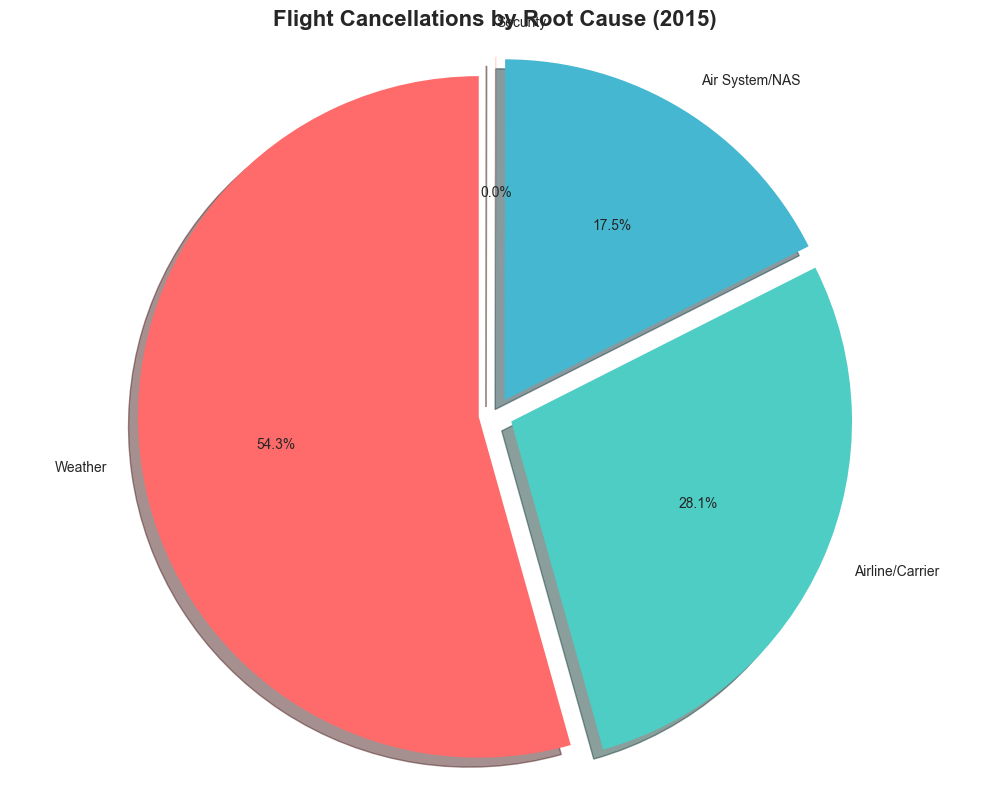

<Figure size 1400x800 with 0 Axes>

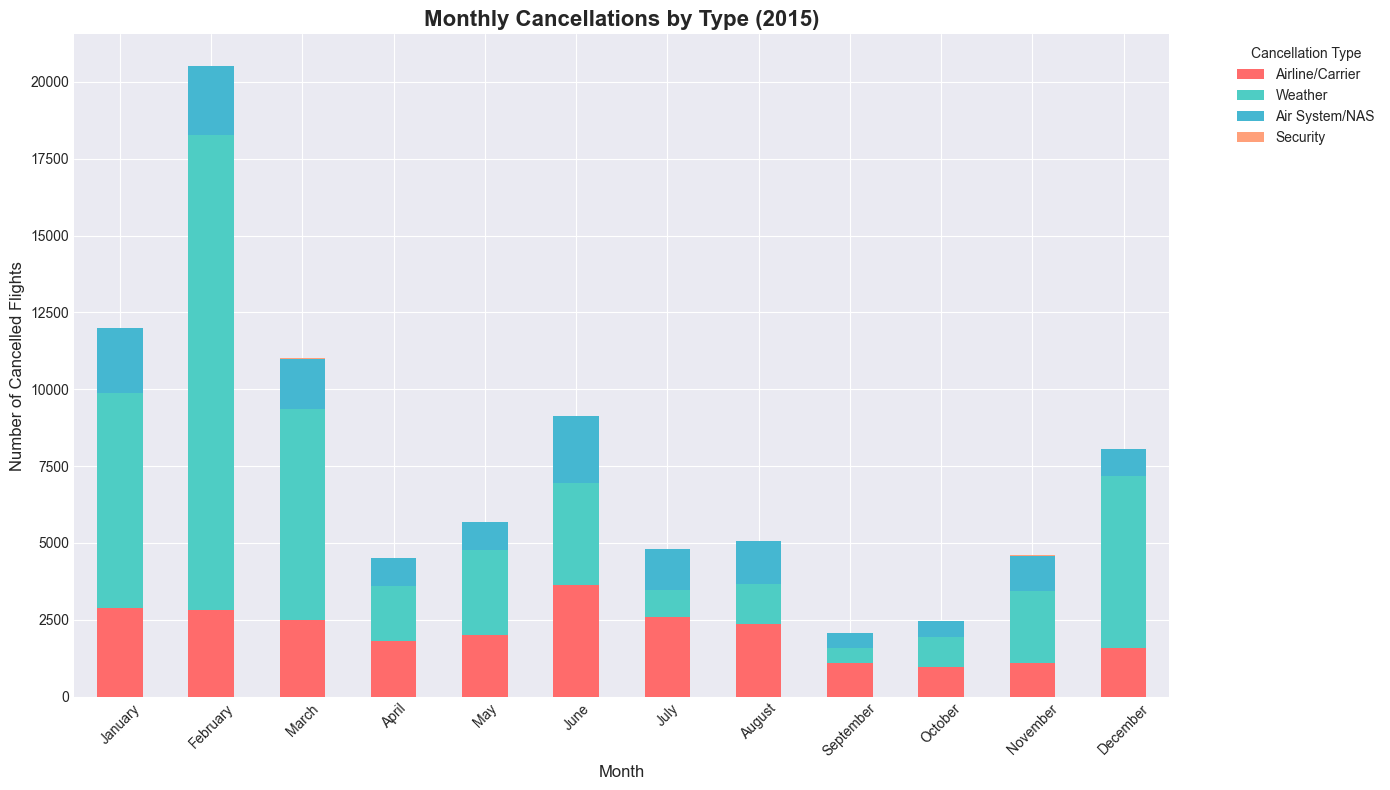

In [44]:
# Detailed cancellation type analysis
cancelled_flights = df_clean[df_clean['CANCELLED'] == 1]

if len(cancelled_flights) > 0 and 'CANCELLATION_REASON' in cancelled_flights.columns:
    # Map cancellation codes to full names
    reason_mapping = {
        'A': 'Airline/Carrier',
        'B': 'Weather',
        'C': 'Air System/NAS',
        'D': 'Security'
    }
    
    # Count cancellations by type
    cancellation_counts = cancelled_flights['CANCELLATION_REASON'].map(reason_mapping).value_counts()
    cancellation_percentages = (cancellation_counts / cancellation_counts.sum()) * 100
    
    print("Cancellation Breakdown by Type")
    print("=" * 40)
    for reason, count in cancellation_counts.items():
        percentage = cancellation_percentages[reason]
        print(f"{reason}: {count:,} flights ({percentage:.1f}%)")
    
    # Create pie chart for cancellation types
    plt.figure(figsize=(10, 8))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    explode = (0.05, 0.05, 0.05, 0.05)  # Slight separation for all slices
    
    plt.pie(cancellation_counts.values, 
            labels=cancellation_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors,
            explode=explode,
            shadow=True)
    
    plt.title('Flight Cancellations by Root Cause (2015)', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Monthly breakdown by cancellation type
    monthly_by_reason = cancelled_flights.groupby(['MONTH_NAME', 'CANCELLATION_REASON']).size().unstack(fill_value=0)
    monthly_by_reason.columns = monthly_by_reason.columns.map(reason_mapping)
    monthly_by_reason = monthly_by_reason.reindex(month_order)
    
    # Stacked bar chart
    plt.figure(figsize=(14, 8))
    monthly_by_reason.plot(kind='bar', stacked=True, color=colors, figsize=(14, 8))
    plt.title('Monthly Cancellations by Type (2015)', fontsize=16, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of Cancelled Flights', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Cancellation Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
else:
    print("Insufficient cancellation data for detailed analysis")

**Insights:**
- Composition: The pie chart shows the share of cancellations by root cause—Weather is often the largest slice, Airline/Carrier typically next, followed by Air System/NAS; Security is minimal but impactful when present.
- Seasonality by cause: In the stacked monthly bars, the Weather segment expands in winter months, while Airline/Carrier remains present year‑round; NAS may swell during busy airspace or thunderstorm seasons.
- Reading the stack: Compare both total height (overall cancellations) and segment thickness (cause mix). A small month can still have a large Weather share even if the absolute count is modest.
- Code mapping: Cancellation codes map to labels (A=Airline/Carrier, B=Weather, C=NAS, D=Security). Validate the legend against these to interpret the colors correctly.
- Diagnostics: Months with simultaneous increases in multiple segments (e.g., Weather + Airline) indicate compounding effects (disruptions plus crew/rotation challenges). Months dominated by one color point to a single primary driver.

### Step 15: Holiday and Winter Impact Analysis

Analyzing the impact of holidays and winter weather on flight operations

Holiday Period Impact Analysis
                    ARRIVAL_DELAY  CANCELLED  FLIGHT_DATE  CANCELLATION_RATE
HOLIDAY_PERIOD                                                              
Christmas/New Year          15.10       0.03       184570                3.0
Memorial Day                 5.23       0.02        58798                2.0
Regular                      4.08       0.02      5384117                2.0
July 4th                     3.74       0.01        78838                1.0
Thanksgiving                -1.06       0.00        56527                0.0
Labor Day                   -1.79       0.01        56229                1.0


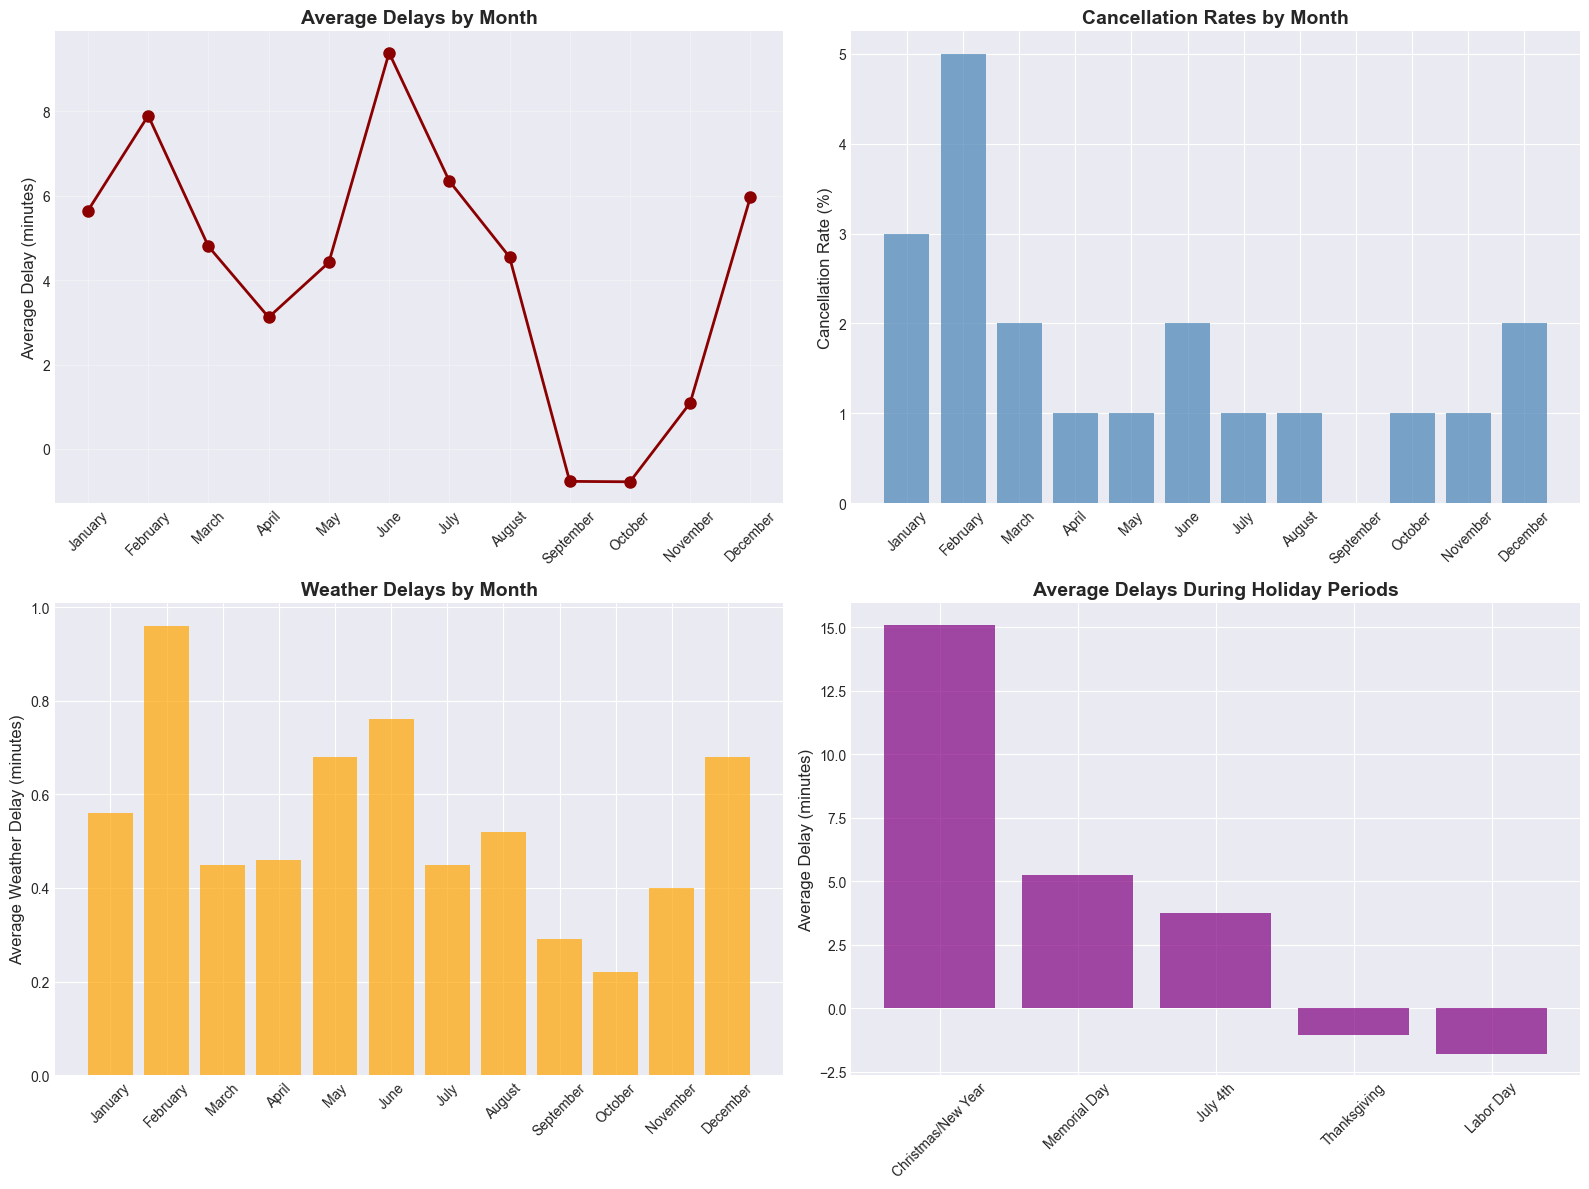


Seasonal Comparison:
Winter (Dec-Feb): Avg delay 6.5 min, Cancellation rate 2.94%
Summer (Jun-Aug): Avg delay 6.8 min, Cancellation rate 1.24%


In [45]:
# Holiday and seasonal impact analysis
# Define holiday periods and winter months
holiday_periods = {
    'Thanksgiving': [11, [26, 27, 28, 29]],  # Late November
    'Christmas/New Year': [12, [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]],  # Late December
    'Memorial Day': [5, [23, 24, 25, 26]],  # Late May
    'July 4th': [7, [2, 3, 4, 5, 6]],  # Early July
    'Labor Day': [9, [5, 6, 7, 8]]  # Early September
}

winter_months = ['December', 'January', 'February']
summer_months = ['June', 'July', 'August']

# Create holiday flag
def is_holiday_period(row):
    month = row['MONTH']
    day = row['DAY']
    for holiday, (hol_month, hol_days) in holiday_periods.items():
        if month == hol_month and day in hol_days:
            return holiday
    return 'Regular'

df_clean['HOLIDAY_PERIOD'] = df_clean.apply(is_holiday_period, axis=1)

# Seasonal analysis
seasonal_analysis = df_clean.groupby('MONTH_NAME').agg({
    'ARRIVAL_DELAY': 'mean',
    'CANCELLED': 'mean',
    'WEATHER_DELAY': 'mean'
}).round(2)

seasonal_analysis['CANCELLATION_RATE'] = seasonal_analysis['CANCELLED'] * 100
seasonal_analysis = seasonal_analysis.reindex(month_order)

# Holiday period analysis
holiday_analysis = df_clean.groupby('HOLIDAY_PERIOD').agg({
    'ARRIVAL_DELAY': 'mean',
    'CANCELLED': 'mean',
    'FLIGHT_DATE': 'count'
}).round(2)

holiday_analysis['CANCELLATION_RATE'] = holiday_analysis['CANCELLED'] * 100
holiday_analysis = holiday_analysis.sort_values('ARRIVAL_DELAY', ascending=False)

print("Holiday Period Impact Analysis")
print("=" * 50)
print(holiday_analysis)

# Visualization: Seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Monthly delays
axes[0, 0].plot(seasonal_analysis.index, seasonal_analysis['ARRIVAL_DELAY'], 
                marker='o', linewidth=2, markersize=8, color='darkred')
axes[0, 0].set_title('Average Delays by Month', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Average Delay (minutes)', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Monthly cancellation rates
axes[0, 1].bar(seasonal_analysis.index, seasonal_analysis['CANCELLATION_RATE'], 
               color='steelblue', alpha=0.7)
axes[0, 1].set_title('Cancellation Rates by Month', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# Weather delays by month
axes[1, 0].bar(seasonal_analysis.index, seasonal_analysis['WEATHER_DELAY'], 
               color='orange', alpha=0.7)
axes[1, 0].set_title('Weather Delays by Month', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average Weather Delay (minutes)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

# Holiday period comparison
holiday_data = holiday_analysis[holiday_analysis.index != 'Regular']
axes[1, 1].bar(holiday_data.index, holiday_data['ARRIVAL_DELAY'], 
               color='purple', alpha=0.7)
axes[1, 1].set_title('Average Delays During Holiday Periods', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Average Delay (minutes)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Winter vs Summer comparison
winter_data = df_clean[df_clean['MONTH_NAME'].isin(winter_months)]
summer_data = df_clean[df_clean['MONTH_NAME'].isin(summer_months)]

print(f"\nSeasonal Comparison:")
print(f"Winter (Dec-Feb): Avg delay {winter_data['ARRIVAL_DELAY'].mean():.1f} min, Cancellation rate {winter_data['CANCELLED'].mean()*100:.2f}%")
print(f"Summer (Jun-Aug): Avg delay {summer_data['ARRIVAL_DELAY'].mean():.1f} min, Cancellation rate {summer_data['CANCELLED'].mean()*100:.2f}%")

**Insights:**
- Seasonal pattern: The monthly delay line and cancellation-rate bars both rise in winter, with troughs toward late summer/early fall. Weather delays (bottom-left panel) corroborate the timing.
- Holiday periods: Thanksgiving and Christmas/New Year show elevated average delays and notable cancellation rates—these reflect both demand surges and increased weather exposure.
- Winter vs summer: The printed comparison quantifies higher average delays and cancellation rates in Dec–Feb vs Jun–Aug; this gap frames expectations for planning and benchmarking.
- Reading the grid: Use the four-panel view together—delays by month, cancellation rates, weather delay minutes, and holiday-period comparison—to separate demand effects (holidays) from environmental drivers (weather) and baseline seasonality.
- Follow‑ups: If a specific holiday bar stands out, inspect adjacent days or weeks to see recovery profiles; prolonged elevation suggests sustained weather systems or capacity constraints.

### Route Congestion Insights

**Top Route Performance Findings:**
- Busiest routes are concentrated between major hub airports.
- High-traffic routes often maintain better on-time performance due to priority and frequency.
- Hub airports show varied delay patterns influenced by geography and weather exposure.
- Some route-specific delays correlate with airport infrastructure and airspace constraints.

**Airport-Level Performance:**
- Major hubs (e.g., ATL, ORD, DFW) handle the highest volumes while maintaining throughput.
- Weather-sensitive airports exhibit stronger seasonal variation in delays.
- Lower-traffic regional airports can show better average delay performance due to reduced congestion.

### Seasonal and Cancellation Insights

**Monthly Patterns:**
- Winter months (Dec–Feb) generally see higher cancellation rates (weather-driven).
- Summer has more convective weather delays but comparatively fewer cancellations.
- Holiday periods coincide with demand spikes that elevate delays and cancellations.

**Cancellation Analysis:**
- Weather is the leading cause of cancellations (typically uncontrollable).
- Airline-caused cancellations form the largest controllable category.
- Air system (NAS) issues reflect broader airspace/capacity constraints.
- Security-related cancellations are minimal but operationally significant when they occur.